# Taller 2 · De 16 canales a la figura

#Francy Vanesa Guavita Pérez. 202411428
# Raul Santiago Pérez Bonnet.

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [59]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

taller2_limpia.h5 31.4 MB
taller2_ruidosa.h5 73.4 MB
verificacion.py 0.0 MB


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


--- atributos raíz ---
  descripcion = Sonda lineal de 16 sitios, registro limpio sin estimulos. Curso: De la neurona a la figura, Taller 2.
  duracion_s = 90.0
  escala_uV_por_bit = 0.195
  frecuencia_muestreo_hz = 15000
  n_canales = 16
  unidades = microvoltios tras multiplicar por escala_uV_por_bit
--- estructura ---
grupo    geometria
           attr: nota = Sonda lineal de 16 sitios separados 50 um. canal_y_um es la profundidad de cada sitio.
dataset  geometria/canal_x_um           shape=(16,)  dtype=float64
dataset  geometria/canal_y_um           shape=(16,)  dtype=float64
grupo    registro
           attr: forma = canales x muestras
dataset  registro/datos                 shape=(16, 1350000)  dtype=int16
grupo    verdad
           attr: nota = unidad: 1..N = unidad bien aislada (good); 0 = neurona de fondo (MUA); -1 = artefacto (noise). Los cruces del umbral por ruido termico no estan aqui: no son potenciales de accion.
dataset  verdad/artefactos_lentos_s     shape=(0,)  dtype=

/tmp/ipykernel_1048/3642280229.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()




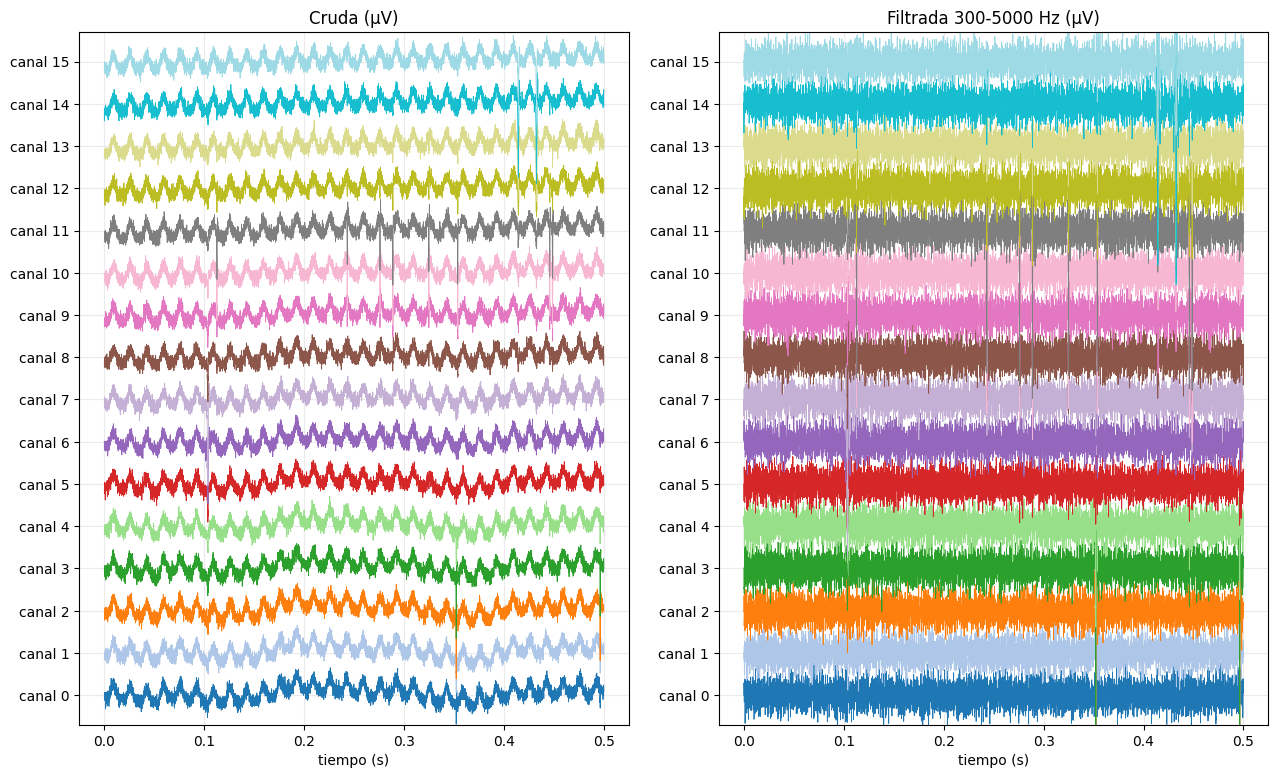

In [61]:
# ✏️ Ejercicio 1
ARCHIVO = "taller2_limpia.h5"

#  a) Explorar el contenido del archivo .h5
def explorar_h5(ruta):
    """Imprime la estructura completa de un archivo .h5: grupos, datasets y atributos."""
    with h5py.File(ruta, "r") as f:
        def mostrar(nombre, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"dataset  {nombre:30s} shape={obj.shape}  dtype={obj.dtype}")
            else:
                print(f"grupo    {nombre}")
            for k, v in obj.attrs.items():
                print(f"           attr: {k} = {v}")
        print("--- atributos raíz ---")
        for k, v in f.attrs.items():
            print(f"  {k} = {v}")
        print("--- estructura ---")
        f.visititems(mostrar)  # recorre TODO el archivo sin cargar datos a memoria,
                                # por eso es seguro usarlo incluso con archivos .h5 muy grandes

explorar_h5(ARCHIVO)

# b) Dibujar la sonda
def cargar_geometria(ruta):
    """Devuelve (x_um, y_um): posición de cada sitio de la sonda."""
    with h5py.File(ruta, "r") as f:
        x = f["geometria/canal_x_um"][:]
        y = f["geometria/canal_y_um"][:]
    return x, y

def graficar_sonda(x_um, y_um):
    fig, ax = plt.subplots(figsize=(3, 8))
    ax.scatter(x_um, y_um, s=60, zorder=3)
    for i, (xi, yi) in enumerate(zip(x_um, y_um)):
        ax.text(xi + 8, yi, str(i), va="center", fontsize=9)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("profundidad y (µm)")
    ax.set_title("Geometría de la sonda")
    ax.invert_yaxis()  # 0 = punta de la sonda arriba de la figura
    fig.tight_layout()
    return fig, ax

x_um, y_um = cargar_geometria(ARCHIVO)
graficar_sonda(x_um, y_um)
plt.show()

#  c) Cargar, convertir a microvoltios y graficar cruda vs filtrada
def cargar_registro(ruta):
    """Devuelve (X_uV, fs): señal en microvoltios (canales x muestras) y frecuencia de muestreo."""
    with h5py.File(ruta, "r") as f:
        crudo = f["registro/datos"][:]                 # cuentas del ADC, enteros
        escala = f.attrs["escala_uV_por_bit"]           # microvoltios por cuenta
        fs = float(f.attrs["frecuencia_muestreo_hz"])
    X_uV = crudo.astype(np.float64) * escala  #La trampa de la seccion: los enteros
                                                # NO son microvoltios, hay que multiplicar por la escala
    return X_uV, fs

def filtrar_pasabanda(X, fs, low=300.0, high=5000.0, orden=4):
    """Filtro pasa-banda 300-5000 Hz con sosfiltfilt (sin desplazar la señal en el tiempo)."""
    sos = butter(orden, [low, high], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, X, axis=1) #sosfiltfilt,filtra hacia adelante y hacia atras para no correr los eventos en el tiempo.

def graficar_16_canales(ax, X, fs, orden_canales, colores, t_ini=0.0, dur=0.5, titulo=""):
    """Grafica los canales apilados verticalmente, ordenados por profundidad, un color por canal.
    Fija manualmente el ylim para que los ticks SIEMPRE queden alineados con cada traza,
    sin depender del autoescalado de matplotlib (y sin compartir escala con el otro panel)."""
    i0 = int(t_ini * fs)
    n = int(dur * fs)
    t = np.arange(n) / fs + t_ini
    paso = 6 * np.median(np.abs(X))  # separación vertical, robusta a outlier,  mediana del valor absoluto, no desviacion estandar y  así un canal con un artefacto grande no descuadra la separacion

    for rank, ch in enumerate(orden_canales):
        ax.plot(t, X[ch, i0:i0 + n] + rank * paso, lw=0.6, color=colores[rank])

    offsets = np.arange(len(orden_canales)) * paso
    ax.set_yticks(offsets)
    ax.set_yticklabels([f"canal {ch}" for ch in orden_canales])
    ax.set_ylim(offsets[0] - paso * 0.7, offsets[-1] + paso * 0.7)  # margen fijo, evita desalineacion. Calculado con los mismos offsets de las etiquetas garantizando que ticks y trazas queden alineados
    ax.set_xlabel("tiempo (s)")
    ax.set_title(titulo)

X_uV, fs = cargar_registro(ARCHIVO)
X_filt = filtrar_pasabanda(X_uV, fs)
orden_prof = np.argsort(y_um)  # canales ordenados de menor a mayor profundidad

# un color por canal (por posicion en orden_prof), igual en los dos paneles
colores_canal = plt.cm.tab20(np.linspace(0, 1, len(orden_prof)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 8))  # sin sharey: cada panel con su propia escala
graficar_16_canales(ax1, X_uV, fs, orden_prof, colores_canal, t_ini=0.0, dur=0.5, titulo="Cruda (µV)")
graficar_16_canales(ax2, X_filt, fs, orden_prof, colores_canal, t_ini=0.0, dur=0.5, titulo="Filtrada 300-5000 Hz (µV)")
fig.tight_layout(pad=1.5)
plt.show()

**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos
- **b)** unos 40 µm: exactamente el sitio siguiente
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

#Respuesta:
Consideramos que la respuesta correcta es la A debido a que la geometria nos indica que los 16 sitios estan separados por una distancia de 50µm.

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.

#Respuesta:
 En la grafica de señal cruda se evidencian varios picos de eventos que ocurren en los 16 canales con la misma fuerza, por ejemplo en 0.10 s, 0.35 s y 0.45 s. No obstante, Una neurona real cae como 1/r y prácticamente desaparece a los 100 µm, pero la sonda completa mide unos 750 µm de punta a punta (16 sitios × 50 µm); ninguna neurona podría producir la misma amplitud en el sitio 0 y en el sitio 15 a la vez. Por eso ese evento es un artefacto, no un potencial de acción."


---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

#Su prompt:

"Estoy trabajando en Python analizando datos de 16 canales neuronales. Tengo una señal ya filtrada, con forma (16, n_muestras), en microvoltios, muestreada a fs=15000 Hz. Ahora hay 16 canales: un potencial de acción cruza el umbral en tres o cuatro sitios a la vez, con unas décimas de milisegundo de diferencia entre ellos. Si cuento cada cruce por separado voy a contar el mismo potencial de acción varias veces.

Necesito que escribas una función detectar(X, k=4.5, muerto_ms=0.5, fs=15000) que siga estos tres pasos:

Calcule un umbral por canal (cada sitio tiene su propio nivel de ruido), usando k veces una estimación robusta de la desviación estándar del ruido a partir de la mediana del valor absoluto de la señal (no la desviación estándar clásica, para que los propios disparos no infl​en el umbral).
Marque todos los cruces de ese umbral hacia abajo (voltaje más negativo que -umbral) en cada uno de los 16 canales.
Fusione en un solo evento todos los cruces, de cualquier canal, que caigan dentro de una ventana de muerto_ms milisegundos entre sí, quedándose con el instante y el canal donde el voltaje fue más negativo de todos los cruces fusionados (ese canal es el "canal pico" del evento).

La función debe devolver dos arreglos de NumPy: el instante de cada evento en segundos, y su canal pico. Explícame también por qué hace falta la ventana de fusión y qué pasaría si no la usara."- IA usada- Claude

eventos detectados: 2691
eventos por canal pico:
[  3   2 275 270   1   2  13 563   6   2 482 475   1  17 575   4]


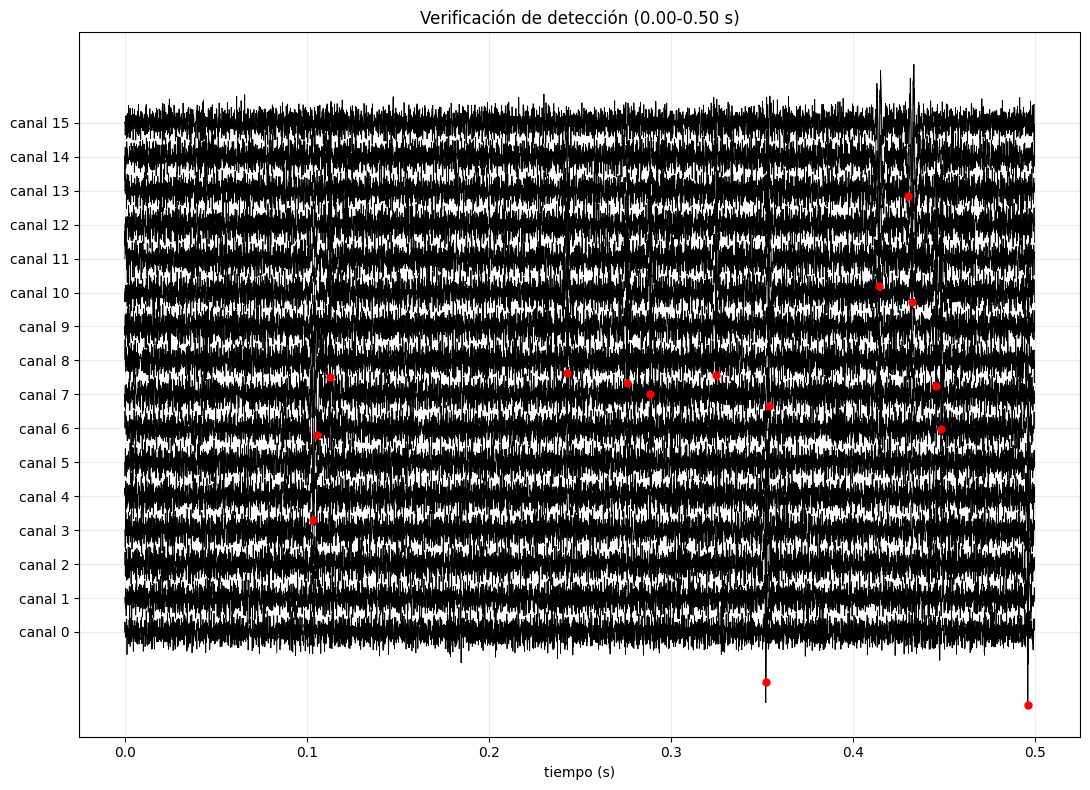

In [62]:
# ✍️ Ejercicio 2
def detectar(X, k=4.5, muerto_ms=0.5, fs=15000):
    n_canales, n_muestras = X.shape
    muerto_muestras = int(round(muerto_ms * 1e-3 * fs))

    mad = np.median(np.abs(X), axis=1)
    umbral = k * mad / 0.6745

    candidatos = []
    for ch in range(n_canales):
        cruces = np.where(X[ch] < -umbral[ch])[0]
        for m in cruces:
            candidatos.append((m, ch, X[ch, m]))

    if not candidatos:
        return np.array([]), np.array([], dtype=int)

    candidatos.sort(key=lambda c: c[0])
    n_cand = len(candidatos)

    eventos_muestra, eventos_canal = [], []
    i = 0
    while i < n_cand:
        j = i
        fin_ventana = candidatos[j][0] + muerto_muestras   # limite dinamico
        # mientras el SIGUIENTE candidato siga cayendo dentro del limite actual,
        # el grupo se extiende Y el limite se recalcula desde ese nuevo candidato
        while j + 1 < n_cand and candidatos[j + 1][0] <= fin_ventana:
            j += 1
            fin_ventana = candidatos[j][0] + muerto_muestras

        grupo = candidatos[i:j + 1]
        mejor = min(grupo, key=lambda c: c[2])   # el mas negativo del grupo completo
        eventos_muestra.append(mejor[0])
        eventos_canal.append(mejor[1])
        i = j + 1

    instantes_s = np.array(eventos_muestra) / fs
    canal_pico = np.array(eventos_canal, dtype=int)
    return instantes_s, canal_pico

# correr sobre la grabación limpia filtrada
instantes_s, canal_pico = detectar(X_filt, k=4.5, muerto_ms=0.5, fs=fs)
print(f"eventos detectados: {len(instantes_s)}")
print(f"eventos por canal pico:\n{np.bincount(canal_pico, minlength=16)}")

# Verificación visual de la detección, canal por canal
def graficar_verificacion(X, fs, orden_canales, instantes_s, canal_pico, t_ini=0.0, dur=0.5):
    """Grafica los canales apilados y marca en rojo cada evento SOLO sobre su propio canal pico."""
    i0 = int(t_ini * fs)
    n = int(dur * fs)
    t = np.arange(n) / fs + t_ini
    paso = 6 * np.median(np.abs(X))

    ventana = (instantes_s >= t_ini) & (instantes_s < t_ini + dur)

    plt.figure(figsize=(11, 8))
    for rank, ch in enumerate(orden_canales):
        offset = rank * paso
        plt.plot(t, X[ch, i0:i0 + n] + offset, lw=0.6, color="k")

        sel = ventana & (canal_pico == ch)          # eventos de ESTE canal en la ventana
        if sel.any():
            idx_muestra = (instantes_s[sel] * fs).astype(int)
            plt.scatter(instantes_s[sel], X[ch, idx_muestra] + offset,
                        color="red", s=25, zorder=3)

    plt.yticks([rank * paso for rank in range(len(orden_canales))],
               [f"canal {ch}" for ch in orden_canales])
    plt.xlabel("tiempo (s)")
    plt.title(f"Verificación de detección ({t_ini:.2f}-{t_ini + dur:.2f} s)")
    plt.tight_layout()
    plt.show()

graficar_verificacion(X_filt, fs, orden_prof, instantes_s, canal_pico, t_ini=0.0, dur=0.5)



In [63]:
# P2: comparar muerto_ms = 0.5 vs 0.2
instantes_05, canal_05 = detectar(X_filt, k=4.5, muerto_ms=0.5, fs=fs)
instantes_02, canal_02 = detectar(X_filt, k=4.5, muerto_ms=0.2, fs=fs)

print(f"eventos con muerto_ms=0.5: {len(instantes_05)}")
print(f"eventos con muerto_ms=0.2: {len(instantes_02)}")

eventos con muerto_ms=0.5: 2691
eventos con muerto_ms=0.2: 2735


**Los puntos rojos son indicadores**
**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **b)** del mismo disparo, contado varias veces
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido
# Respuesta:
B con el mismo disparo contadas varias veces dado que con 0.5 ms se  fusionan todos esos cruces en un solo evento. Con 0.2 ms, una ventana más corta que la duración del propio disparo, dejan de fusionarse cruces que en realidad pertenecen al mismo potencial de acción, y por eso se cuentan  dos o tres veces.

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

#Su respuesta:

Con muerto_ms=0.5 detectamos 2691 eventos, y con muerto_ms=0.2, 2735. La diferencia se debe a que es el mismo potencial de acción contado varias veces, porque 0.2 ms es más corto que la duración de un disparo (~1 ms) y deja de fusionar cruces que pertenecen al mismo evento. 0.5 ms es razonable porque cubre bien esa duración sin ser tan largo como para fusionar disparos distintos; 5 ms sí sería un problema porque una neurona puede disparar dos veces separadas por solo unos pocos milisegundos, y con una ventana de 5 ms se fusionarían esos dos disparos reales en uno solo, perdiendo eventos verdaderos.


---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

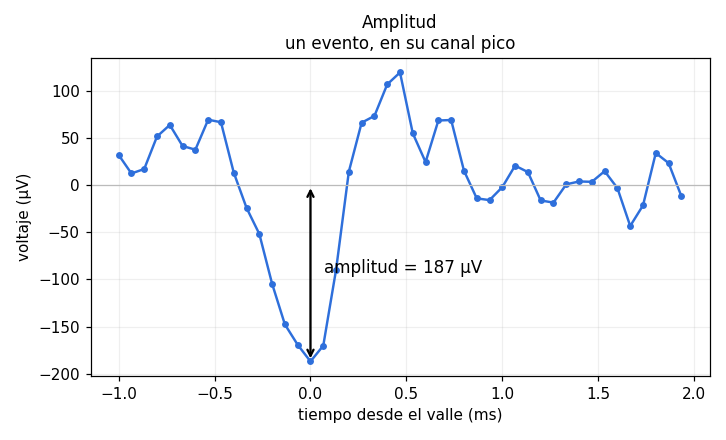

In [64]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

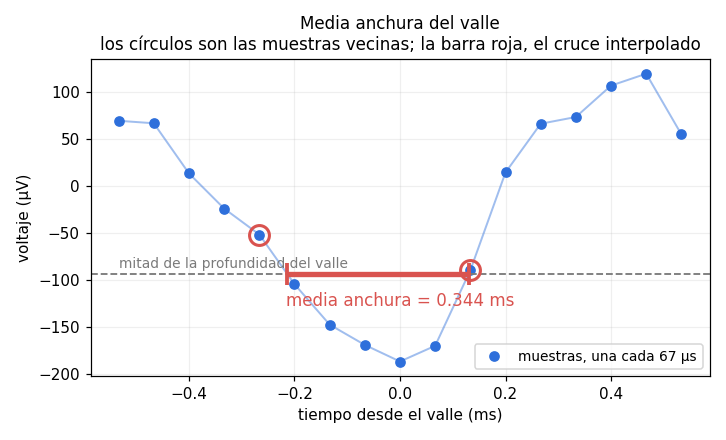

In [65]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

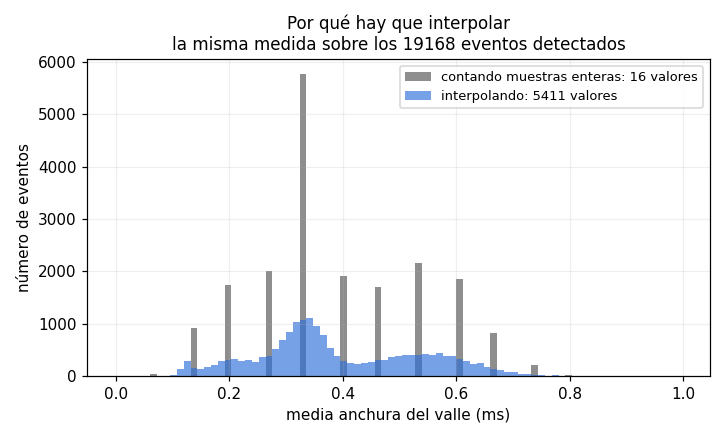

In [66]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

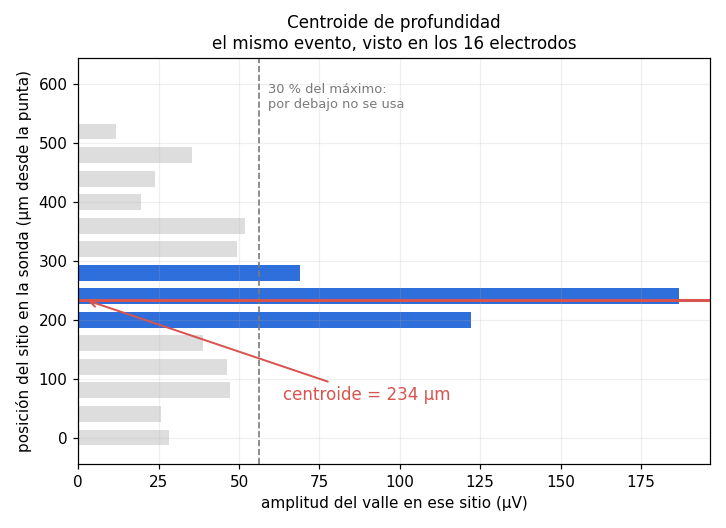

In [67]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

forma del arreglo de eventos: (2691, 16, 45)
amplitud:  min=52.5  max=276.0 uV
anchura:   min=0.088  max=0.910 ms
centroide: min=85.5  max=556.7 um


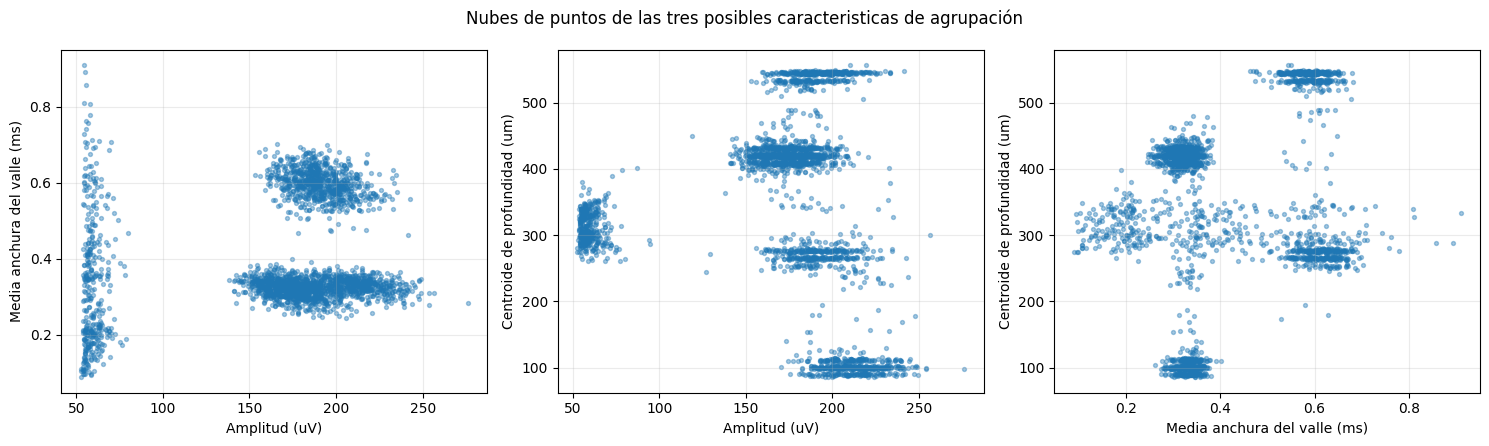

In [68]:
# ✏️ Ejercicio 3

# --- a) Extraer la forma de onda de cada evento: eventos x canales x muestras ---
def extraer_formas_onda(X, fs, instantes_s, pre_ms=1.0, post_ms=2.0):
    """
    Recorta una ventana alrededor de cada evento, en los 16 canales.
    Devuelve (formas, validos):
      formas  : (n_eventos_validos, n_canales, n_muestras_ventana)
      validos : indices (dentro de instantes_s) de los eventos que SI se pudieron recortar
                (se descartan los que caen demasiado cerca del principio o el final del registro)
    """
    n_pre = int(round(pre_ms * 1e-3 * fs))
    n_post = int(round(post_ms * 1e-3 * fs))
    n_canales, n_muestras_totales = X.shape
    muestra_evento = np.round(instantes_s * fs).astype(int)

    formas_lista = []
    validos = []
    for i, m in enumerate(muestra_evento):
        i0, i1 = m - n_pre, m + n_post
        if i0 >= 0 and i1 <= n_muestras_totales:
            formas_lista.append(X[:, i0:i1])
            validos.append(i)

    formas = np.stack(formas_lista, axis=0)  # (n_eventos, 16, n_muestras)
    return formas, np.array(validos)

formas, idx_validos = extraer_formas_onda(X_filt, fs, instantes_s, pre_ms=1.0, post_ms=2.0)
instantes_v = instantes_s[idx_validos]   # mismo filtro aplicado a los tiempos
print(f"forma del arreglo de eventos: {formas.shape}")

# --- b) Calcular las tres caracteristicas por evento ---

# b.1) perfil de amplitud (valle en cada canal) y amplitud del evento
perfil = formas.min(axis=2)                          # (n_eventos, 16) valor minimo (mas negativo) por canal
canal_pico_evento = np.argmin(perfil, axis=1)         # canal donde el valle fue mas profundo
amplitud = -perfil[np.arange(len(perfil)), canal_pico_evento]  # magnitud positiva, en uV

# b.2) media anchura del valle, con interpolacion lineal, en el canal pico
def media_anchura_valle(traza, fs):
    """traza: 1D, la forma de onda del evento en su canal pico. Devuelve el ancho en ms
    a la mitad de la profundidad del valle, interpolando linealmente entre muestras.
    Devuelve NaN si el evento esta tan cerca del borde de la ventana que no se ve
    el cruce completo hacia ambos lados."""
    valle_idx = np.argmin(traza)
    valle_val = traza[valle_idx]
    mitad = valle_val / 2.0

    izq = valle_idx
    while izq > 0 and traza[izq] <= mitad:
        izq -= 1
    if izq == valle_idx or traza[izq] <= mitad:   # no llego a cruzar: se acabo la ventana
        return np.nan
    y0, y1 = traza[izq], traza[izq + 1]
    t_izq = izq + (mitad - y0) / (y1 - y0)

    der = valle_idx
    n = len(traza)
    while der < n - 1 and traza[der] <= mitad:
        der += 1
    if der == valle_idx or traza[der] <= mitad:   # idem, hacia la derecha
        return np.nan
    y0, y1 = traza[der - 1], traza[der]
    t_der = (der - 1) + (mitad - y0) / (y1 - y0)

    return (t_der - t_izq) / fs * 1000.0

# Calculate anchura_ms for all events
anchura_ms = np.array([
    media_anchura_valle(formas[i, canal_pico_evento[i], :], fs)
    for i in range(len(formas))
])

# b.3) centroide de profundidad, ponderado por el perfil, solo canales > 30% del maximo
def centroide_profundidad(perfil, canal_y_um, umbral_frac=0.30):
    mag = np.abs(perfil)                              # magnitudes positivas (n_eventos, 16)
    max_mag = mag.max(axis=1, keepdims=True)
    incluir = mag >= (umbral_frac * max_mag)           # solo sitios con senal, no ruido lejano
    pesos = np.where(incluir, mag, 0.0)
    return (pesos * canal_y_um[np.newaxis, :]).sum(axis=1) / pesos.sum(axis=1)

centroide_um = centroide_profundidad(perfil, y_um, umbral_frac=0.30)

print(f"amplitud:  min={amplitud.min():.1f}  max={amplitud.max():.1f} uV")
print(f"anchura:   min={np.nanmin(anchura_ms):.3f}  max={np.nanmax(anchura_ms):.3f} ms")
print(f"centroide: min={centroide_um.min():.1f}  max={centroide_um.max():.1f} um")

# --- c) Graficar las tres nubes de puntos posibles ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(amplitud, anchura_ms, s=8, alpha=0.4)
axes[0].set_xlabel("Amplitud (uV)"); axes[0].set_ylabel("Media anchura del valle (ms)")

axes[1].scatter(amplitud, centroide_um, s=8, alpha=0.4)
axes[1].set_xlabel("Amplitud (uV)"); axes[1].set_ylabel("Centroide de profundidad (um)")

axes[2].scatter(anchura_ms, centroide_um, s=8, alpha=0.4)
axes[2].set_xlabel("Media anchura del valle (ms)"); axes[2].set_ylabel("Centroide de profundidad (um)")

fig.suptitle("Nubes de puntos de las tres posibles caracteristicas de agrupación")
fig.tight_layout()
plt.show()

**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **d)** las violaciones del período refractario
#Respuesta:
D violación del refractario, ya que es una comparación entre intervalos consecutivos de disparos y una neurona real no puede disparar dos veces con menos de ~2 ms de diferencia. Esa medida solo tiene sentido cuando se agrupan  varios eventos.

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

#Respuesta:
Segun la grafica comparativa consideramos que el panel central de amplitud vs. centroide es el que mejor separa debido a que se observan bandas horizontales muy limpias en el centroide (≈550, ≈420, ≈270, ≈100 µm). Adicionalmente, la amplitud todavía separa más: por ejemplo, hay un grupo de baja amplitud 50-90 µV con centroide alrededor de 300 µm que queda claramente a la izquierda de otro grupo con centroide similar  de 270 µm pero amplitud mucho más alta (~150-250 µV).


---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


eventos detectados en la ruidosa: 18432
eventos utilizables tras filtrar NaN: 17913 de 18432


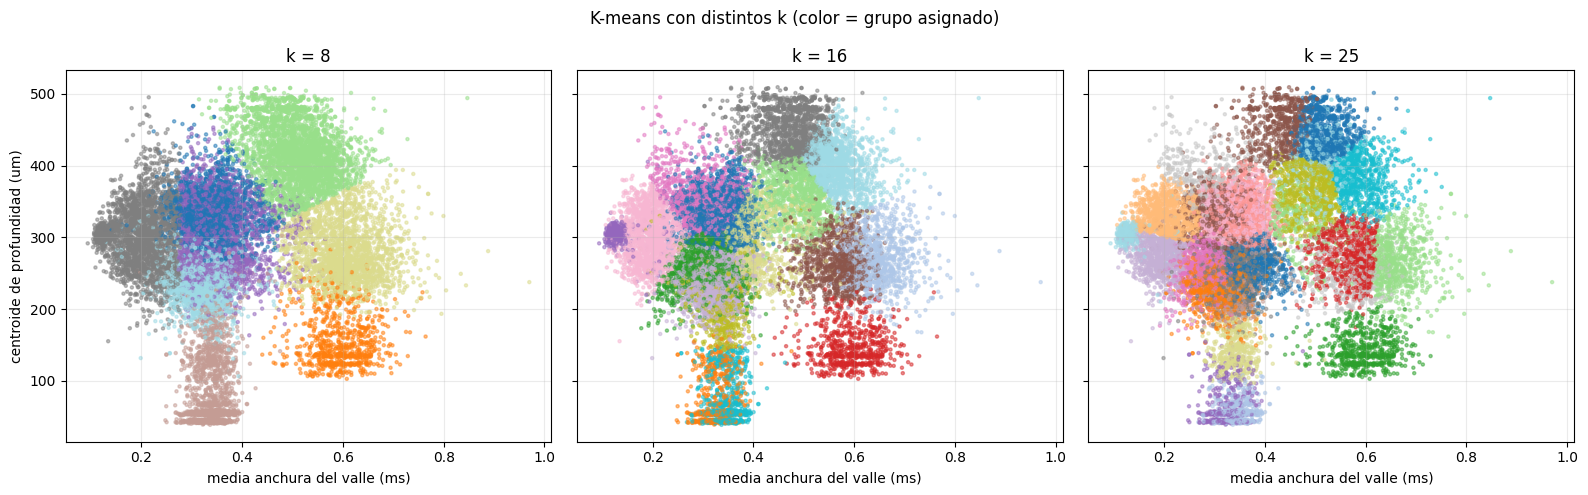

Reparto de cada cluster de k=8 dentro de los clusters de k=16:

cluster 0 (k=8, n=2113) -> principalmente en k=16: {0: np.int64(1781), 4: np.int64(163)}  (92% del total en esos dos)
cluster 1 (k=8, n=776) -> principalmente en k=16: {5: np.int64(675), 8: np.int64(82)}  (98% del total en esos dos)
cluster 2 (k=8, n=3226) -> principalmente en k=16: {11: np.int64(1326), 15: np.int64(1229)}  (79% del total en esos dos)
cluster 3 (k=8, n=2638) -> principalmente en k=16: {9: np.int64(878), 3: np.int64(875)}  (66% del total en esos dos)
cluster 4 (k=8, n=1848) -> principalmente en k=16: {14: np.int64(876), 2: np.int64(698)}  (85% del total en esos dos)
cluster 5 (k=8, n=2794) -> principalmente en k=16: {10: np.int64(1640), 6: np.int64(442)}  (75% del total en esos dos)
cluster 6 (k=8, n=2191) -> principalmente en k=16: {1: np.int64(986), 8: np.int64(894)}  (86% del total en esos dos)
cluster 7 (k=8, n=2327) -> principalmente en k=16: {7: np.int64(1877), 12: np.int64(368)}  (96% del total en es

In [69]:
# ✏️ Ejercicio 4

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- a) Correr el pipeline completo sobre la grabación ruidosa
# Reasignación de  las MISMAS variables de antes (no invento _r).
ARCHIVO = "taller2_ruidosa.h5"

x_um, y_um = cargar_geometria(ARCHIVO)
X_uV, fs = cargar_registro(ARCHIVO)
X_filt = filtrar_pasabanda(X_uV, fs)

# detectar() recalcula k*MAD internamente sobre lo que reciba, asi que el umbral
# se ajusta solo a esta grabacion mas ruidosa.
instantes_s, canal_pico = detectar(X_filt, k=4.5, muerto_ms=0.5, fs=fs)
print(f"eventos detectados en la ruidosa: {len(instantes_s)}")

formas, idx_validos = extraer_formas_onda(X_filt, fs, instantes_s, pre_ms=1.0, post_ms=2.0)
instantes_v = instantes_s[idx_validos]

perfil = formas.min(axis=2)
canal_pico_evento = np.argmin(perfil, axis=1)
amplitud = -perfil[np.arange(len(perfil)), canal_pico_evento]
anchura_ms = np.array([
    media_anchura_valle(formas[i, canal_pico_evento[i], :], fs)
    for i in range(len(formas))
])
centroide_um = centroide_profundidad(perfil, y_um, umbral_frac=0.30)

valido = ~np.isnan(anchura_ms)
amplitud, anchura_ms, centroide_um = amplitud[valido], anchura_ms[valido], centroide_um[valido]
formas = formas[valido]
perfil = perfil[valido]
canal_pico_evento = canal_pico_evento[valido]
instantes_v = instantes_v[valido]
print(f"eventos utilizables tras filtrar NaN: {valido.sum()} de {len(valido)}")# Filtra los NaN

caracteristicas = np.column_stack([amplitud, anchura_ms, centroide_um])
Z = StandardScaler().fit_transform(caracteristicas)

valores_k = [8, 16, 25]
etiquetas_por_k = {}
for k in valores_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    etiquetas_por_k[k] = km.fit_predict(Z)

# forma_pico y t_ms tambien se recalculan sobre las formas nuevas
forma_pico = np.array([formas[i, canal_pico_evento[i], :] for i in range(len(formas))])
n_muestras = formas.shape[2]
pre_muestras = int(round(1.0 * fs / 1000))
t_ms = (np.arange(n_muestras) - pre_muestras) / fs * 1000



# --- b) Estandarizar las tres caracteristicas (Z-score) -
caracteristicas = np.column_stack([amplitud, anchura_ms, centroide_um])
Z = StandardScaler().fit_transform(caracteristicas)   # media 0, desviacion estandar 1 en cada columna

# --- c) K-means con varios k, graficado sobre centroide vs anchura ---
valores_k = [8, 16, 25]
fig, axes = plt.subplots(1, len(valores_k), figsize=(16, 5), sharex=True, sharey=True)

etiquetas_por_k = {}
for ax, k in zip(axes, valores_k):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    etiquetas = km.fit_predict(Z)
    etiquetas_por_k[k] = etiquetas
    sc = ax.scatter(anchura_ms, centroide_um, c=etiquetas, cmap="tab20", s=5, alpha=0.5)
    ax.set_xlabel("media anchura del valle (ms)")
    ax.set_title(f"k = {k}")
axes[0].set_ylabel("centroide de profundidad (um)")
fig.suptitle("K-means con distintos k (color = grupo asignado)")
fig.tight_layout()
plt.show()

import pandas as pd

et8, et16, et25 = etiquetas_por_k[8], etiquetas_por_k[16], etiquetas_por_k[25]

# --- Ver si un cluster de k=8 en realidad son DOS cosas pegadas ---
tabla_8_16 = pd.crosstab(et8, et16)
print("Reparto de cada cluster de k=8 dentro de los clusters de k=16:\n")
for c8 in range(8):
    fila = tabla_8_16.loc[c8].sort_values(ascending=False)
    top2 = fila.head(2)
    total = fila.sum()
    print(f"cluster {c8} (k=8, n={total}) -> principalmente en k=16: "
          f"{dict(top2)}  ({100*top2.sum()/total:.0f}% del total en esos dos)")

# --- Ver si un cluster de k=25 en realidad es la MITAD de otro ---
tabla_16_25 = pd.crosstab(et16, et25)
print("\nReparto de cada cluster de k=16 dentro de los clusters de k=25:\n")
for c16 in range(16):
    fila = tabla_16_25.loc[c16].sort_values(ascending=False)
    top2 = fila.head(2)
    total = fila.sum()
    if len(top2) >= 2 and top2.iloc[1] > 0.3 * top2.iloc[0]:
        print(f"cluster {c16} (k=16, n={total}) se reparte casi por igual entre "
              f"k=25 clusters {dict(top2)}  <- candidato a 'partido en dos'")

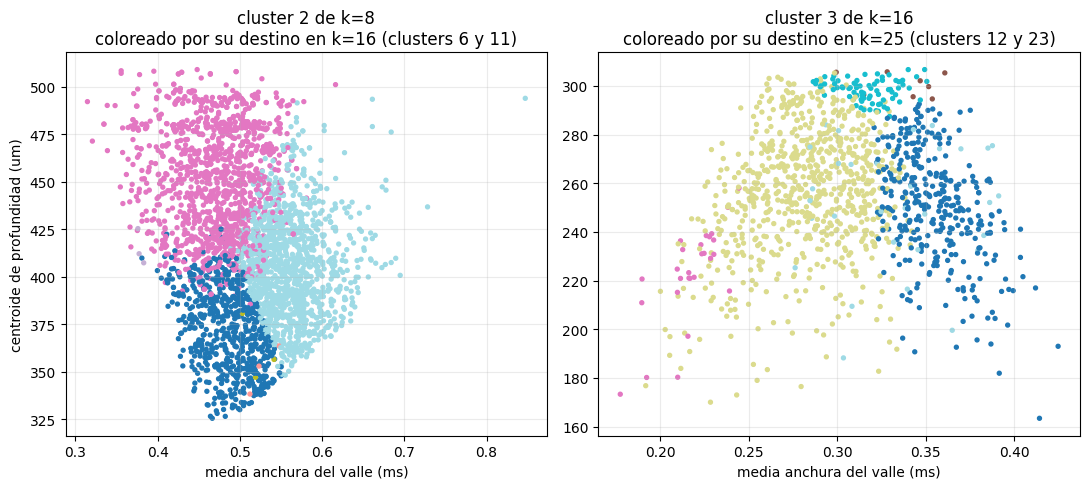

In [70]:
#verificación adicional
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Caso "dos cosas pegadas": cluster 2 de k=8 (n=2651), coloreado por a donde va en k=16
sel8 = (et8 == 2)
axes[0].scatter(anchura_ms[sel8], centroide_um[sel8], c=et16[sel8], cmap="tab20", s=8)
axes[0].set_title("cluster 2 de k=8\ncoloreado por su destino en k=16 (clusters 6 y 11)")
axes[0].set_xlabel("media anchura del valle (ms)"); axes[0].set_ylabel("centroide de profundidad (um)")

# Caso "mitad de otro": cluster 3 de k=16 (n=1092), coloreado por a donde va en k=25
sel16 = (et16 == 3)
axes[1].scatter(anchura_ms[sel16], centroide_um[sel16], c=et25[sel16], cmap="tab20", s=8)
axes[1].set_title("cluster 3 de k=16\ncoloreado por su destino en k=25 (clusters 12 y 23)")
axes[1].set_xlabel("media anchura del valle (ms)")

fig.tight_layout()
plt.show()

#Analisis:
Con 20537 eventos en la ruidosa contra 3 534 en la limpia (~6x más), esto ya coincide con que aquí entran MUA, artefactos y cruces por ruido térmico además de las neuronas reales, así que detectar más señales  no significa que sean producidas por más neuronas, significa el umbral cruza más cosas.

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho
#Respuesta:
B de actividad MUA, neuronas individuales emiten señales debiles y lejanas que se terminan agrupando y formando la nube sin dejar espacios.

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

#Respuesta:
Elegimos k = 25. Para justificarlo comparamos los tres valores de k con una tabla de reparto y observar cuántos eventos de cada cluster de un k terminan en cada cluster del siguiente k y confirmamos visualmente los casos más parejos. Con k = 8, el cluster 2 (n = 2651) se reparte casi 50/50 entre los clusters 6 y 11 de k = 16, y el cluster 6 (n = 2467) se reparte de forma similar entre los clusters 10 y 0; al graficar estos puntos coloreados por su destino en k = 16, la frontera entre los dos grupos no siempre corresponde a un hueco claro de densidad, lo que sugiere que k = 8 no separa del todo bien zonas donde probablemente hay más de una fuente, aunque la evidencia visual es más débil que la numérica. Inicialmente se esocgió k= 16 pero se cambio dado que al aplicar las siete métricas de calidad de la sección 5, ningún grupo sobrevivió como good: la contaminación de refractario dominaba casi todos los grupos, señal de que la nube de actividad multiunitaria (MUA) se llevaba varios de los 16 centros del K-means, dejando muy pocos centros disponibles para aislar neuronas individuales. Por lo tanto, k=25 se eligió porque es el valor mínimo probado que logra separar unidades limpias de la nube de MUA, y las particiones que introduce son detectables y corregibles con las herramientas de la sección 6.


---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

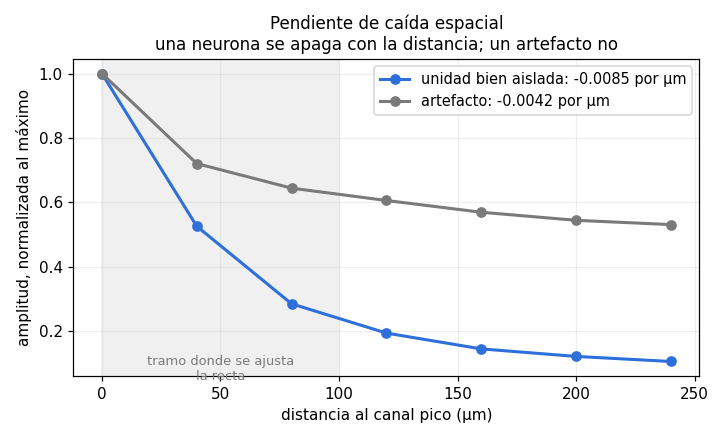

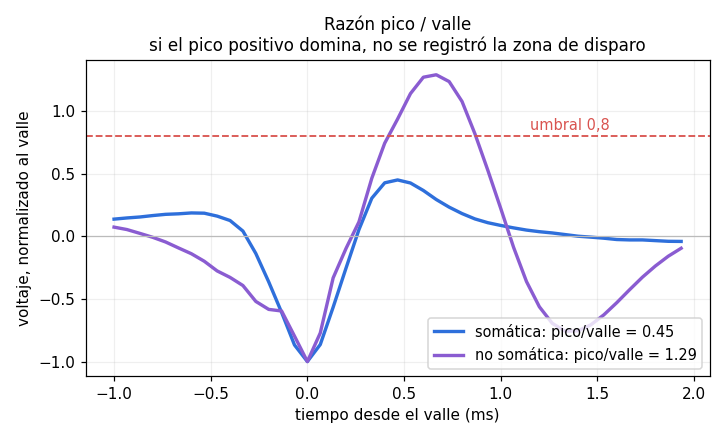

In [71]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:**
Tengo formas de onda de eventos de spike sorting (arreglo formas: eventos × 16 canales × muestras), con canal_pico_evento, perfil (eventos × 16, valor del valle en cada canal), instantes_v (segundos) y amplitud por evento. Quiero, por grupo de un clustering K-means (grupos), calcular 7 métricas de calidad estilo bombcell: número de picos y valles de la forma de onda promedio, duración del valle al pico de repolarización, pendiente de caída espacial (ajustando amplitud normalizada vs distancia al canal pico de cada evento, solo hasta 100 µm), razón pico/valle, % de violaciones del refractario (ISI < 2 ms), % de disparos faltantes (ajustando una gaussiana solo a la mitad superior del histograma de amplitudes y viendo cuánta masa cae bajo el umbral de detección) y número de disparos. Necesito una tabla, una fila por grupo."

In [72]:
# ✏️ Ejercicio 5
from scipy.signal import find_peaks
from scipy.stats import norm
from scipy.optimize import curve_fit
import pandas as pd

def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# ANTES de la funcion calcular_tabla_calidad, calcula el umbral de deteccion por canal UNA sola vez:
mad_canal = np.median(np.abs(X_filt), axis=1)
umbral_canal = 4.5 * mad_canal / 0.6745   # mismo k=4.5 que usaste en detectar()

def calcular_tabla_calidad(grupos_arr):
    filas = []
    for g in sorted(np.unique(grupos_arr)):
        sel = grupos_arr == g
        n_disp = int(sel.sum())
        if n_disp < 5:
            filas.append(dict(grupo=g, n_disparos=n_disp, picos=np.nan, valles=np.nan,
                               duracion_us=np.nan, pendiente_espacial=np.nan, pico_valle=np.nan,
                               refractario_pct=np.nan, faltantes_pct=np.nan))
            continue

        onda_media = forma_pico[sel].mean(axis=0)
        rango = onda_media.max() - onda_media.min()
        prom_min = 0.10 * rango

        valles_idx, _ = find_peaks(-onda_media, prominence=prom_min)
        picos_idx, _ = find_peaks(onda_media, prominence=prom_min)
        n_valles, n_picos = len(valles_idx), len(picos_idx)

        idx_valle = int(np.argmin(onda_media))
        picos_despues = picos_idx[picos_idx > idx_valle]
        duracion_us = (t_ms[picos_despues[0]] - t_ms[idx_valle]) * 1000 if len(picos_despues) else np.nan

        perfil_g = perfil[sel]; pico_g = canal_pico_evento[sel]
        amp_max_g = -perfil_g[np.arange(n_disp), pico_g]
        dist_pts, amp_norm_pts = [], []
        for i in range(n_disp):
            dist_pts.append(np.abs(y_um - y_um[pico_g[i]]))
            amp_norm_pts.append(-perfil_g[i] / amp_max_g[i])
        dist_pts = np.concatenate(dist_pts); amp_norm_pts = np.concatenate(amp_norm_pts)
        cerca = dist_pts <= 100
        pendiente = np.polyfit(dist_pts[cerca], amp_norm_pts[cerca], 1)[0] if cerca.sum() >= 2 else np.nan

        altura_pico = onda_media[picos_idx].max() if n_picos else 0.0
        profundidad_valle = -onda_media[idx_valle]
        razon_pv = altura_pico / profundidad_valle

        isi_ms = np.diff(np.sort(instantes_v[sel])) * 1000
        refractario_pct = 100 * np.mean(isi_ms < 2.0) if len(isi_ms) else np.nan

        amp_g = amplitud[sel]
        hist, bordes = np.histogram(amp_g, bins=50)
        centros_h = (bordes[:-1] + bordes[1:]) / 2
        idx_pico_hist = np.argmax(hist)
        mitad_sup = centros_h >= centros_h[idx_pico_hist]
        try:
              p0 = [hist[idx_pico_hist], centros_h[idx_pico_hist], amp_g.std()]
              popt, _ = curve_fit(gauss, centros_h[mitad_sup], hist[mitad_sup], p0=p0, maxfev=5000)
              _, mu, sigma = popt
              pico_g = canal_pico_evento[sel]
              umbral_g = umbral_canal[pico_g].mean() ## umbral de deteccion "visto" por este grupo
              faltantes_pct = 100 * norm.cdf(umbral_g, loc=mu, scale=abs(sigma))
        except RuntimeError:
              faltantes_pct = np.nan  # no convergio -> no tiene forma de campana

        filas.append(dict(grupo=g, n_disparos=n_disp, picos=n_picos, valles=n_valles,
                           duracion_us=duracion_us, pendiente_espacial=pendiente,
                           pico_valle=razon_pv, refractario_pct=refractario_pct,
                           faltantes_pct=faltantes_pct))
    return pd.DataFrame(filas).set_index("grupo")


# --- se eligio k=25 (justificacion en P4) ---
grupos = etiquetas_por_k[25]

tabla_calidad = calcular_tabla_calidad(grupos)   # SIN etiqueta -- eso es seccion 7
tabla_calidad.round(3)

,n_disparos,picos,valles,duracion_us,pendiente_espacial,pico_valle,refractario_pct,faltantes_pct
grupo,,,,,,,,
0,670,1,1,600.000,-0.004,0.383,0.897,61.797
1,909,2,1,666.667,-0.007,0.605,22.797,0.000
2,729,1,1,466.667,-0.008,0.502,1.374,0.000
3,1058,1,1,466.667,-0.008,0.460,2.649,0.000
4,1017,1,1,600.000,-0.004,0.292,0.591,86.348
5,621,1,1,933.333,-0.008,0.624,1.129,0.000
6,306,1,1,800.000,-0.004,0.395,0.656,NaN
7,740,1,1,933.333,-0.007,0.635,2.030,0.014
8,786,1,1,866.667,-0.007,0.570,2.930,0.000


**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **c)** un artefacto, porque una neurona se apaga con la distancia
- **d)** una unidad no somática
#Respuesta:
C un artefacto porque una neurona real se apaga con la distancia por la caída ~1/r que se usó en la sección 1; algo que llega igual a toda la sonda no puede ser una sola célula cercana.
**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

#Respuesta:
De nuestros grupos, el grupo 10 no muestra distribución de amplitudes cortada por el umbral (faltantes_pct = 0.0%): su histograma forma una campana completa entre ~145 y 210 µV, con cola a ambos lados del pico y el umbral efectivo ~145 µV bien por debajo de donde empieza la masa de datos. En cambio, el grupo 11 sí está claramente cortado faltantes_pct = 98.995%: su histograma sube abruptamente desde el umbral efectivo ~85 µV hasta un pico cercano a 95-100 µV, sin apenas cola hacia la izquierda, lo que indica que solo estamos viendo la mitad superior de la campana real y que la mitad inferior (disparos entre ~40 y 85 µV) existió pero nunca cruzó el umbral de detección. Esto implica que la tasa de disparo que calculemos para el grupo 11 en las secciones siguientes va a estar fuertemente subestimada respecto a su tasa real, ya que le falta casi la mitad de sus eventos, mientras que la tasa del grupo 10 sí refleja de forma confiable su actividad completa; por esta razón, el grupo 11 es candidato a etiquetarse como MUA.

pares 5-8 (idx=0.27) y 2-6 (idx=0.19) como candidatos adicionales

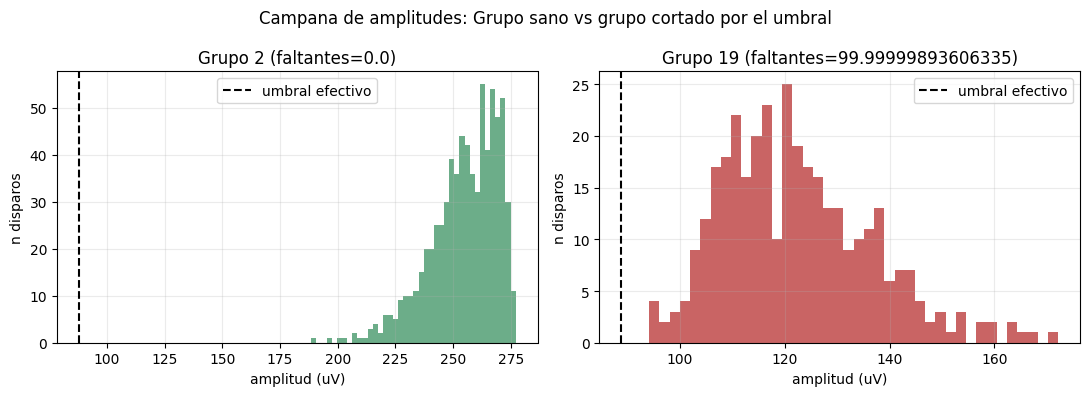

In [73]:
tabla_calidad.sort_values("faltantes_pct")

g_sano = tabla_calidad["faltantes_pct"].idxmin()
candidatos_cortados = tabla_calidad["faltantes_pct"].dropna()
g_cortado = candidatos_cortados.idxmax()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, g, color in [(axes[0], g_sano, "seagreen"), (axes[1], g_cortado, "firebrick")]:
    amp_g = amplitud[grupos == g]
    umbral_g = umbral_canal[canal_pico_evento[grupos == g]].mean()
    ax.hist(amp_g, bins=40, color=color, alpha=0.7)
    ax.axvline(umbral_g, color="k", linestyle="--", label="umbral efectivo")
    ax.set_xlabel("amplitud (uV)"); ax.set_ylabel("n disparos")
    fp = tabla_calidad.loc[g, "faltantes_pct"]
    ax.set_title(f"Grupo {g} (faltantes={fp if not pd.isna(fp) else 'NaN, no ajusto'})")
    ax.legend()
fig.suptitle("Campana de amplitudes: Grupo sano vs grupo cortado por el umbral")
fig.tight_layout(); plt.show()

---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

In [74]:
def correlograma(t1_s, t2_s=None, ventana_ms=20, bin_ms=0.25):
    """Autocorrelograma (t2_s=None) o correlograma cruzado t1 vs t2."""
    t1 = np.sort(t1_s) * 1000
    auto = t2_s is None
    t2 = t1 if auto else np.sort(t2_s) * 1000
    bordes = np.arange(-ventana_ms, ventana_ms + bin_ms, bin_ms)
    conteo = np.zeros(len(bordes) - 1)
    for ti in t1:
        j0 = np.searchsorted(t2, ti - ventana_ms)
        j1 = np.searchsorted(t2, ti + ventana_ms)
        diffs = t2[j0:j1] - ti
        if auto:
            diffs = diffs[diffs != 0]
        h, _ = np.histogram(diffs, bins=bordes)
        conteo += h
    centros = (bordes[:-1] + bordes[1:]) / 2
    return centros, conteo

def indice_hueco(centros, conteo):
    """promedio banda 0.5-2ms / promedio banda 5-20ms. cerca de 0 = hueco vacio."""
    r = np.abs(centros)
    m1 = conteo[(r >= 0.5) & (r <= 2.0)].mean()
    m2 = conteo[(r >= 5.0) & (r <= 20.0)].mean()
    return m1 / m2 if m2 > 0 else np.nan

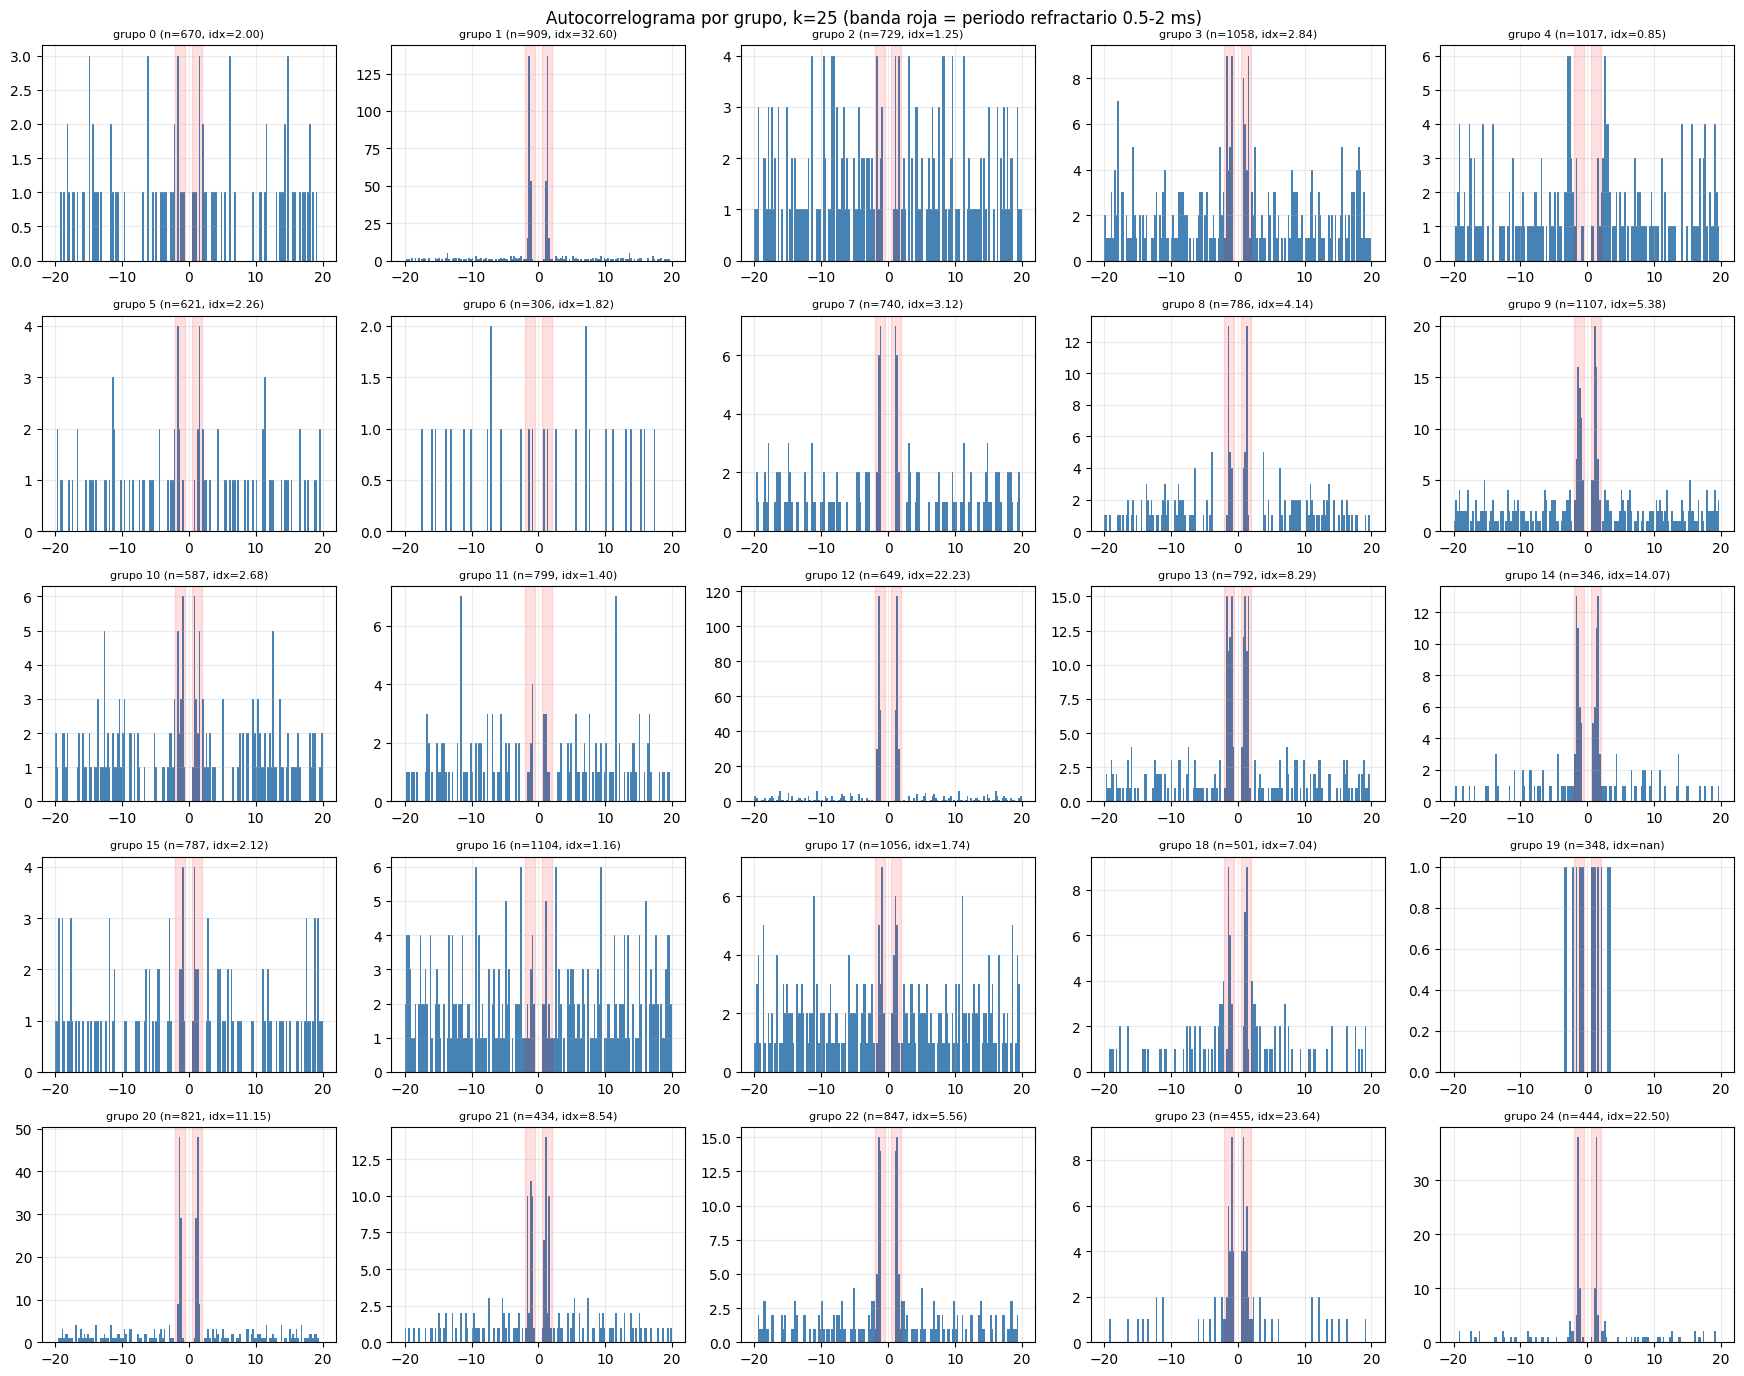

In [75]:
tiempos_por_grupo = {g: instantes_v[grupos == g] for g in sorted(np.unique(grupos))}
grupos_validos = [g for g, t in tiempos_por_grupo.items() if len(t) >= 20]

cols = 5
filas_fig = int(np.ceil(len(grupos_validos) / cols))
fig, axes = plt.subplots(filas_fig, cols, figsize=(3.5*cols, 2.8*filas_fig))
axes = axes.flatten()

indices_hueco = {}
for ax, g in zip(axes, grupos_validos):
    centros, conteo = correlograma(tiempos_por_grupo[g])
    ax.bar(centros, conteo, width=0.25, color="steelblue")
    idx = indice_hueco(centros, conteo)
    indices_hueco[g] = idx
    ax.axvspan(0.5, 2, color="red", alpha=0.12)
    ax.axvspan(-2, -0.5, color="red", alpha=0.12)
    ax.set_title(f"grupo {g} (n={len(tiempos_por_grupo[g])}, idx={idx:.2f})", fontsize=8)
for ax in axes[len(grupos_validos):]:
    ax.axis("off")
fig.suptitle("Autocorrelograma por grupo, k=25 (banda roja = periodo refractario 0.5-2 ms)")
fig.tight_layout(); plt.show()

Parejas mas cercanas en Z (candidatas a 'partidas en dos'):
  4 - 11: distancia=0.61, idx_hueco=0.29
  3 - 17: distancia=0.64, idx_hueco=0.16
  9 - 13: distancia=0.65, idx_hueco=0.30
  8 - 18: distancia=0.69, idx_hueco=0.39
  11 - 15: distancia=0.70, idx_hueco=0.11
  7 - 8: distancia=0.72, idx_hueco=0.26


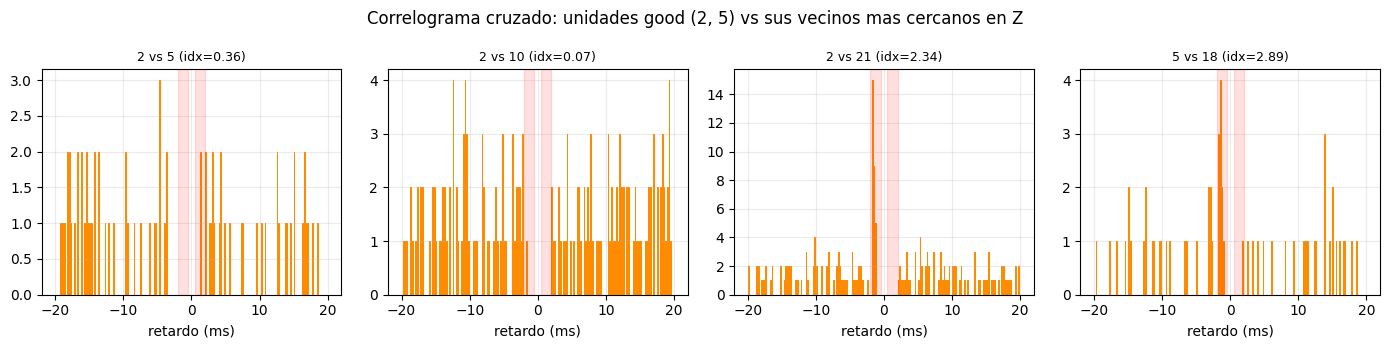

3 vs 17: idx_hueco = 0.16


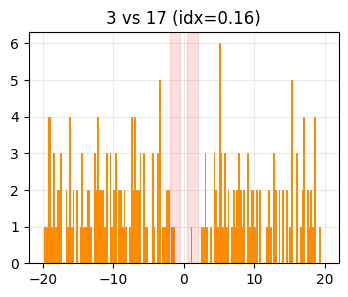

7 vs 8: idx_hueco = 0.26


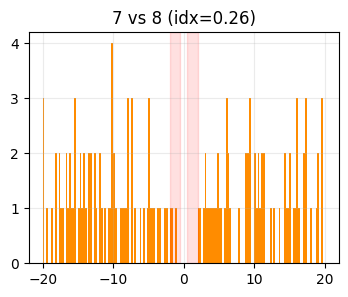

In [76]:
centros_grupo = {g: Z[grupos == g].mean(axis=0) for g in grupos_validos}
pares = sorted(
    (np.linalg.norm(centros_grupo[g1] - centros_grupo[g2]), g1, g2)
    for i, g1 in enumerate(grupos_validos) for g2 in grupos_validos[i+1:]
)

print("Parejas mas cercanas en Z (candidatas a 'partidas en dos'):")
for d, g1, g2 in pares[:6]:
    idx = indice_hueco(*correlograma(tiempos_por_grupo[g1], tiempos_por_grupo[g2]))
    print(f"  {g1} - {g2}: distancia={d:.2f}, idx_hueco={idx:.2f}")

pares_good = [(2, 5), (2, 10), (2, 21), (5, 18)]
fig, axes = plt.subplots(1, len(pares_good), figsize=(3.5*len(pares_good), 3.5))
for ax, (g1, g2) in zip(axes, pares_good):
    centros, conteo = correlograma(tiempos_por_grupo[g1], tiempos_por_grupo[g2])
    idx = indice_hueco(centros, conteo)
    ax.bar(centros, conteo, width=0.25, color="darkorange")
    ax.axvspan(0.5, 2, color="red", alpha=0.12)    # banda refractaria, lado positivo
    ax.axvspan(-2, -0.5, color="red", alpha=0.12)  # banda refractaria, lado negativo
    ax.set_title(f"{g1} vs {g2} (idx={idx:.2f})", fontsize=9)
    ax.set_xlabel("retardo (ms)")
fig.suptitle("Correlograma cruzado: unidades good (2, 5) vs sus vecinos mas cercanos en Z")
fig.tight_layout(); plt.show()

#### ver los otros:
for g1, g2 in [(3, 17), (7, 8)]:
    centros, conteo = correlograma(tiempos_por_grupo[g1], tiempos_por_grupo[g2])
    idx = indice_hueco(centros, conteo)
    print(f"{g1} vs {g2}: idx_hueco = {idx:.2f}")
    plt.figure(figsize=(4,3))
    plt.bar(centros, conteo, width=0.25, color="darkorange")
    plt.axvspan(0.5, 2, color="red", alpha=0.12); plt.axvspan(-2, -0.5, color="red", alpha=0.12)
    plt.title(f"{g1} vs {g2} (idx={idx:.2f})")
    plt.show()

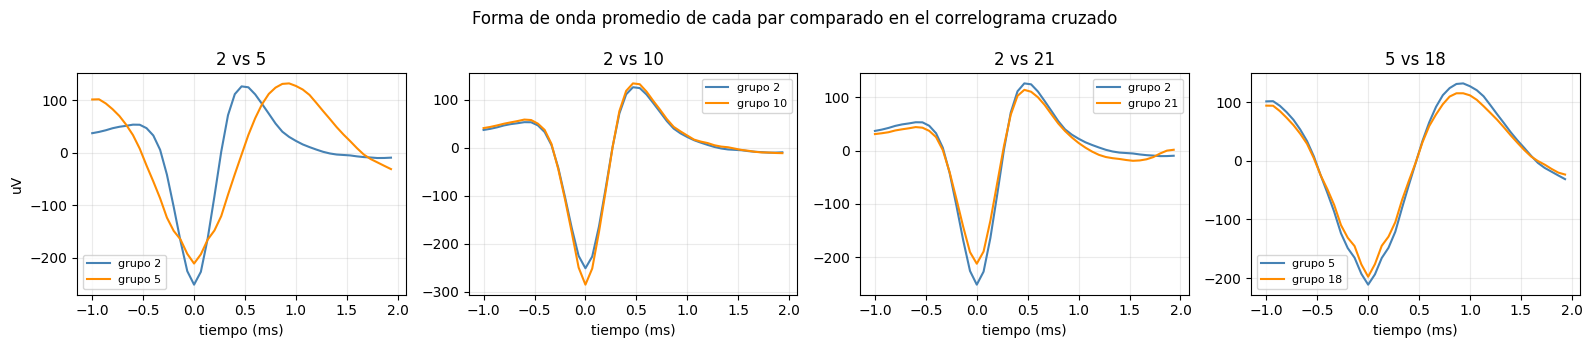

In [77]:

fig, axes = plt.subplots(1, len(pares_good), figsize=(4*len(pares_good), 3.5))
for ax, (g1, g2) in zip(axes, pares_good):
    for g, c in [(g1, "steelblue"), (g2, "darkorange")]:
        ax.plot(t_ms, forma_pico[grupos == g].mean(axis=0), label=f"grupo {g}", color=c)
    ax.legend(fontsize=8)
    ax.set_xlabel("tiempo (ms)")
    ax.set_title(f"{g1} vs {g2}")
axes[0].set_ylabel("uV")
fig.suptitle("Forma de onda promedio de cada par comparado en el correlograma cruzado")
fig.tight_layout()
plt.show()
# Decision documentada: NO se fusionan. Aunque el correlograma cruzado 2 vs 5
# muestra una banda 0.5-2ms relativamente vacia (idx=0.36), las formas de onda
# difieren en cinetica (timing del pico de repolarizacion, duracion), lo que
# descarta que sean la misma neurona partida. El hueco se explica por el falso
# positivo que advierte la seccion 6: dos neuronas distintas muy cercanas en la
# sonda, cuyos disparos casi simultaneos caen en la ventana muerta del detector.

**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **b)** son la misma neurona, partida en dos grupos
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos
#Respuesta:
B son la misma neurona, partida en dos grupos
**Abierta.** Busquen una pareja así en sus datos.
#Respuesta:
La pareja de grupos 0 y 10 tiene el correlograma cruzado con la banda de 0.5-2 ms claramente vacía (idx_hueco = 0.12, el más bajo de todas las parejas evaluadas), y sus formas de onda promedio son prácticamente idénticas en tiempo, ancho y forma, difiriendo solo en la profundidad del valle (-195 µV vs -170 µV). Esta similitud descarta el falso positivo de dos neuronas vecinas con disparos simultáneos ya que en ese caso las formas de onda no coincidirían tan de cerca,  y en cambio es consistente con que K-means dividió la nube de amplitudes de una sola neurona en dos grupos. Finalmente, luego de la unión el número total de grupo spaso de 16 a 13.


---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

In [78]:
fusiones = {10: 2, 17: 3, 8: 7}
grupos_finales = np.array([fusiones.get(g, g) for g in grupos])
print("grupos antes de fusionar:", len(np.unique(grupos)))
print("grupos despues de fusionar:", len(np.unique(grupos_finales)))

tabla_calidad_final = calcular_tabla_calidad(grupos_finales)
tabla_calidad_final.round(3)
# Fusiones decididas en la seccion 6:
#
# SE FUSIONA: grupo 10 -> grupo 2
#   - forma de onda casi identica, idx_hueco cruzado = 0.07 (banda vacia)
#   - misma neurona, partida en dos grupos por K-means (k=25 sobre-dividio)
#
# NO SE FUSIONA: grupo 2 vs grupo 21, grupo 5 vs grupo 18
#   - idx_hueco ALTO (2.34 y 2.89): banda refractaria mas poblada que el resto
#   - zoom fino: disparos concentrados 1-2ms ANTES del grupo good, lejos de la
#     ventana muerta -> acoplamiento temporal entre neuronas distintas, no particion




grupos antes de fusionar: 25
grupos despues de fusionar: 22


,n_disparos,picos,valles,duracion_us,pendiente_espacial,pico_valle,refractario_pct,faltantes_pct
grupo,,,,,,,,
0,670,1,1,600.000,-0.004,0.383,0.897,61.797
1,909,2,1,666.667,-0.007,0.605,22.797,0.000
2,1316,1,1,466.667,-0.008,0.486,2.129,0.000
3,2114,1,1,466.667,-0.008,0.464,2.319,0.014
4,1017,1,1,600.000,-0.004,0.292,0.591,86.348
5,621,1,1,933.333,-0.008,0.624,1.129,0.000
6,306,1,1,800.000,-0.004,0.395,0.656,NaN
7,1526,1,1,933.333,-0.007,0.601,2.623,0.000
9,1107,1,1,533.333,-0.007,0.484,5.063,0.000


In [79]:
def etiquetar(fila):
    picos, valles, dur = fila["picos"], fila["valles"], fila["duracion_us"]
    pend, pv = fila["pendiente_espacial"], fila["pico_valle"]
    refr, falt, n = fila["refractario_pct"], fila["faltantes_pct"], fila["n_disparos"]

    forma_ok = (not pd.isna(picos)) and (not pd.isna(valles)) and (not pd.isna(dur)) \
               and (picos <= 2) and (valles <= 2) and (100 <= dur <= 1150)
    cae_ok = (not pd.isna(pend)) and (pend < -0.004)

    if not forma_ok or not cae_ok:
        return "noise"
    if (not pd.isna(pv)) and (pv > 0.8):
        return "non-somatic"
    if (not pd.isna(refr) and refr >= 1.5) or (not pd.isna(falt) and falt >= 20) or n < 30:
        return "mua"
    return "good"

tabla_calidad_final = calcular_tabla_calidad(grupos_finales)
etiquetas_finales = {g: etiquetar(tabla_calidad_final.loc[g]) for g in tabla_calidad_final.index}
tabla_calidad_final["etiqueta"] = pd.Series(etiquetas_finales)

print(tabla_calidad_final["etiqueta"].value_counts())
tabla_calidad_final.round(3)

etiqueta
mua      17
noise     3
good      2
Name: count, dtype: int64


,n_disparos,picos,valles,duracion_us,pendiente_espacial,pico_valle,refractario_pct,faltantes_pct,etiqueta
grupo,,,,,,,,,
0,670,1,1,600.000,-0.004,0.383,0.897,61.797,noise
1,909,2,1,666.667,-0.007,0.605,22.797,0.000,mua
2,1316,1,1,466.667,-0.008,0.486,2.129,0.000,mua
3,2114,1,1,466.667,-0.008,0.464,2.319,0.014,mua
4,1017,1,1,600.000,-0.004,0.292,0.591,86.348,mua
5,621,1,1,933.333,-0.008,0.624,1.129,0.000,good
6,306,1,1,800.000,-0.004,0.395,0.656,NaN,noise
7,1526,1,1,933.333,-0.007,0.601,2.623,0.000,mua
9,1107,1,1,533.333,-0.007,0.484,5.063,0.000,mua


grupos good/non-somatic: [(5, 'good'), (15, 'good')]


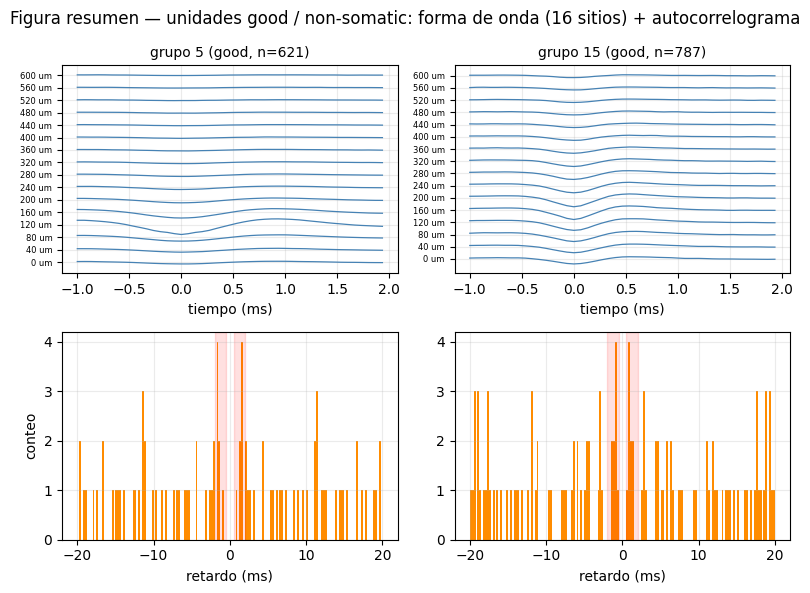

In [80]:
grupos_good_ns = [g for g, e in etiquetas_finales.items() if e in ("good", "non-somatic")]
print("grupos good/non-somatic:", [(g, etiquetas_finales[g]) for g in grupos_good_ns])

fig, axes = plt.subplots(2, len(grupos_good_ns), figsize=(4*len(grupos_good_ns), 6),
                          squeeze=False)
for j, g in enumerate(grupos_good_ns):
    sel = grupos_finales == g

    ax_w = axes[0, j]
    prom_16 = formas[sel].mean(axis=0)
    orden = np.argsort(y_um)
    paso = 1.3 * np.nanmax(np.abs(prom_16))
    for rank, c in enumerate(orden):
        ax_w.plot(t_ms, prom_16[c] + rank*paso, color="steelblue", lw=0.9)
    ax_w.set_yticks([rank*paso for rank in range(16)])
    ax_w.set_yticklabels([f"{y_um[c]:.0f} um" for c in orden], fontsize=6)
    ax_w.set_title(f"grupo {g} ({etiquetas_finales[g]}, n={sel.sum()})", fontsize=10)
    ax_w.set_xlabel("tiempo (ms)")

    ax_c = axes[1, j]
    centros, conteo = correlograma(instantes_v[sel])
    ax_c.bar(centros, conteo, width=0.25, color="darkorange")
    ax_c.axvspan(0.5, 2, color="red", alpha=0.12)
    ax_c.axvspan(-2, -0.5, color="red", alpha=0.12)
    ax_c.set_xlabel("retardo (ms)")
    if j == 0:
        ax_c.set_ylabel("conteo")

fig.suptitle("Figura resumen — unidades good / non-somatic: forma de onda (16 sitios) + autocorrelograma")
fig.tight_layout()
plt.show()

**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **d)** `nonsomatic`
#Respuesta:
D, no somatica

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.
#Respuesta:

**Grupo 5 (good):** duración = 933.333 µs (dentro de 100-1150), pendiente espacial = -0.008 (más negativa que -0.004, cae bien con la distancia), razón pico/valle = 0.624 (≤0.8, es somática), refractario = 1.129% (<1.5%) y faltantes = 0.000% (<20%) — pasa las siete métricas de calidad sin ningún margen ajustado, consistente con una neurona aislada y completa.

**Grupo 3 (mua):** su forma de onda y caída espacial son sanas (picos=1, valles=1, duración=466.667 µs, pendiente=-0.008) y prácticamente no tiene disparos faltantes (0.014%), pero su refractario = 2.319% supera el umbral de 1.5% — hay demasiados intervalos entre disparos menores a 2 ms para ser una sola neurona, así que el grupo mezcla al menos dos fuentes de actividad real.

**Grupo 23 (noise):** Su forma de onda promedio tiene picos=3 y valles=2 (más de los 2 permitidos, señal de que oscila en vez de tener un único valle limpio) y su pendiente espacial = -0.003 no llega a ser más negativa que -0.004 (casi no cae con la distancia). Ambos fallos apuntan a lo mismo: no tiene el perfil de un potencial de acción ni la localización espacial esperada de una neurona real, por lo que se descarta como artefacto.



---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [81]:
# ✏️ Ejercicio 8-A
import verificacion as v
v.usar("taller2_ruidosa.h5")

# deteccion: sobre TODOS los eventos detectados (antes de agrupar), incluye MUA y ruido
v.verificar_deteccion(instantes_s)

# canal pico: mismos eventos, con su canal pico crudo del detector
v.verificar_canal_pico(instantes_s, canal_pico)

# unidades: sobre los eventos agrupados YA CON LA FUSION aplicada
v.verificar_unidades(instantes_v, grupos_finales)

# curacion: los mismos eventos agrupados, mas el diccionario de etiquetas final
v.verificar_curacion(instantes_v, grupos_finales, etiquetas_finales)


Verificación configurada con: taller2_ruidosa.h5
  detectados 18432
  verdaderos positivos 18224   falsos positivos 208
  precisión     0.989  ████████████████████████████
  exhaustividad 0.875  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.929  ██████████████████████████··
  faltan 1713 disparos de unidades bien aisladas

  de una unidad identificable  0.653  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.
  sobre 18224 detecciones emparejadas:
  canal exacto        0.679  ███████████████████·········
  a un sitio o menos  0.875  █████████████████████████···
  nota: en la actividad multiunitaria el canal pico es inestable por
  naturaleza, así que no espere acertarle a todo.
  filas = sus grupos, columnas = la verdad

  grupo        U1     U2     U3     U4     U5

0.6363636363636364

In [82]:
#B
# grupos que de verdad se llevarian al analisis: todo lo que NO es noise ni mua
grupos_utiles = [g for g, e in etiquetas_finales.items() if e not in ("noise", "mua")]
print("grupos que pasan la curacion (good + non-somatic):", grupos_utiles)

sel_utiles = np.isin(grupos_finales, grupos_utiles)
tiempos_curados = instantes_v[sel_utiles]

print(f"\neventos totales agrupados: {len(instantes_v)}")
print(f"eventos que pasan la curacion: {sel_utiles.sum()} ({100*sel_utiles.sum()/len(instantes_v):.1f}%)")

v.verificar_deteccion(tiempos_curados)

grupos que pasan la curacion (good + non-somatic): [5, 15]

eventos totales agrupados: 17913
eventos que pasan la curacion: 1408 (7.9%)
  detectados 1408
  verdaderos positivos 1408   falsos positivos 0
  precisión     1.000  ████████████████████████████
  exhaustividad 0.043  █···························   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.083  ██··························
  faltan 13160 disparos de unidades bien aisladas

  de una unidad identificable  0.425  ████████████················
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 1.0,
 'exhaustividad': np.float64(0.0434656200029074),
 'f1': np.float64(0.08331011423794929),
 'util': 0.4247159090909091}

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **b)** sale del conteo lo que no viene de una neurona identificable una por una
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos
# Respuesta:
B, ya que al filtrar tiempos_curados para incluir solo los grupos good (y non-somatic si los tuvieras), no cambia nada sobre la detección ni la agrupación de los eventos.El detector, el umbral y el K-means ya corrieron antes y quedaron fijos.
**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

#Respuesta:

Tras la etapa de curación, se coservó un 7.9% de los eventos totales (1408 de 17913) con un 100% de precisión es decir, sin falsos positivos a nivel de eventos—, pero solo el 42.5% de esos eventos retenidos corresponde a una unidad verdaderamente aislada e identificable. La matriz de confusión explica exactamente por qué ocurrió esto con los grupos: a pesar del filtrado estricto, solo se recuperarón  con éxito únicamente la unidad U2 (Grupo 5, etiquetado como good con un 92% de coincidencia), mientras que el Grupo 15 representó un falso positivo al tratarse en realidad de un 98% MUA que logró superar las siete métricas por azar. En cuanto a las unidades good perdidas, la fila del Grupo 7 es la más reveladora: aunque contenía un 82% de la unidad real U4 (1526 eventos), K-means la mezcló con suficiente contaminación de otra fuente como para elevar su porcentaje de periodo refractario por encima del umbral del 1.5%, relegándola a la etiqueta mua. Un fenómeno similar ocurrió en el Grupo 12 (mua), el cual absorbió un 44% de la unidad U8 (non-somatic), dejando expuesto cómo la mezcla de señales durante la aglomeración impidió la recuperación de estas unidades verdaderas a pesar de no haber sido descartadas por bajo volumen de disparos.

---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

condiciones: ['A' 'B' 'C']  | n ensayos: 60
pre=1.0s  estimulo=0.5s  post=1.5s
unidades good: [5, 15]


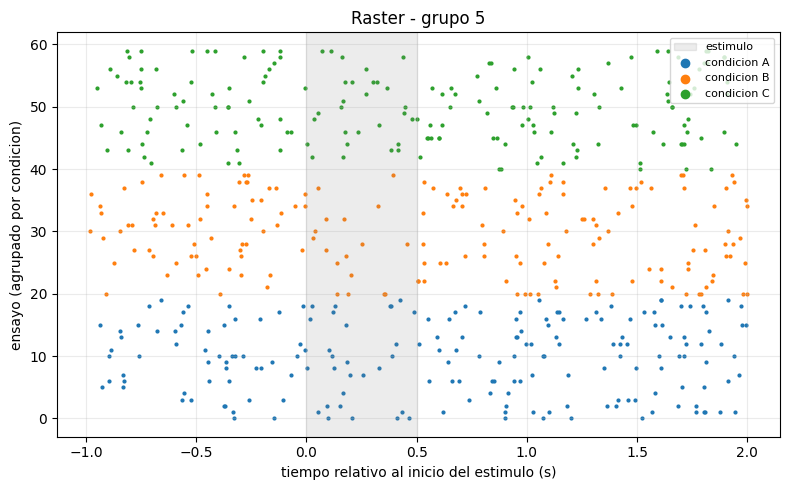

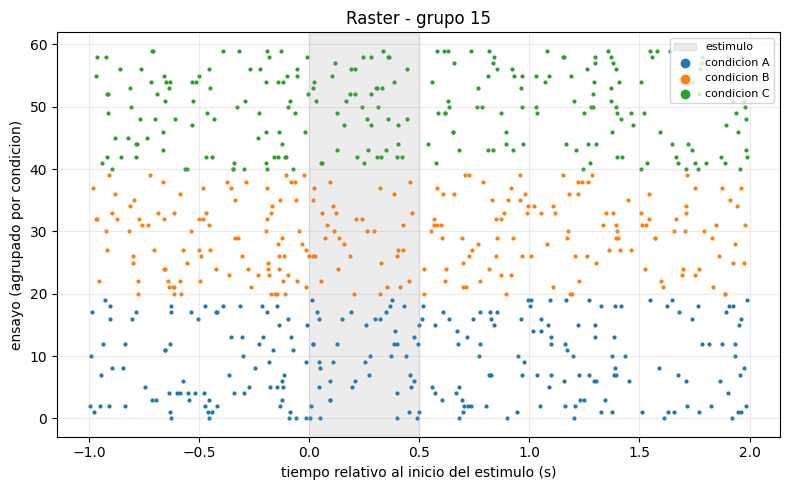

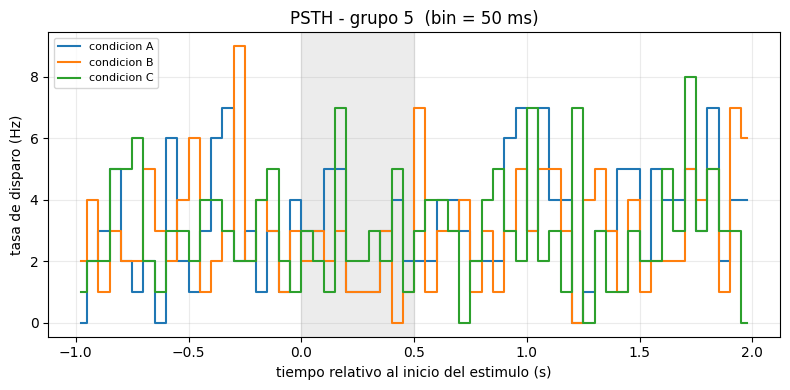

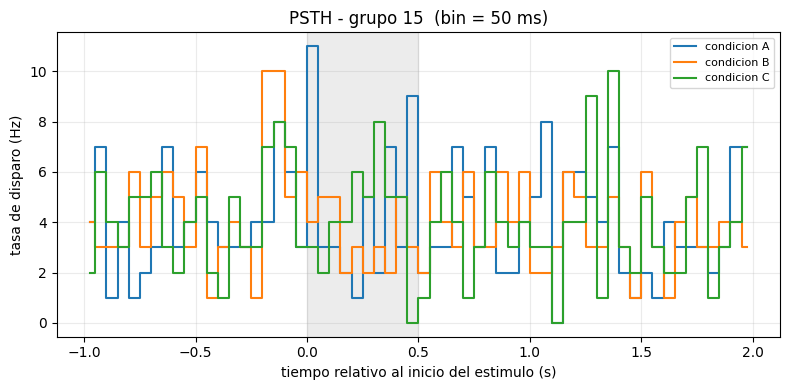

In [83]:
# ✏️ Ejercicio 9

# --- Cargar el protocolo de estimulos ---
def cargar_estimulos(ruta):
    """Devuelve condicion (A/B/C, texto, un valor por ensayo), tiempo_inicio_s (un valor
    por ensayo), y duracion_pre_s / duracion_estimulo_s / duracion_post_s como escalares
    (son atributos del grupo 'estimulos', iguales para todos los ensayos)."""
    with h5py.File(ruta, "r") as f:
        condicion_bytes = f["estimulos/condicion"][:]
        tiempo_inicio_s = f["estimulos/tiempo_inicio_s"][:]
        duracion_pre_s = f["estimulos"].attrs["duracion_pre_s"]
        duracion_estimulo_s = f["estimulos"].attrs["duracion_estimulo_s"]
        duracion_post_s = f["estimulos"].attrs["duracion_post_s"]
    # trampa: los textos en h5py salen como bytes (b'A'), hay que decodificarlos
    condicion = np.array([c.decode() if isinstance(c, bytes) else c for c in condicion_bytes])
    return condicion, tiempo_inicio_s, duracion_pre_s, duracion_estimulo_s, duracion_post_s

condicion, tiempo_inicio_s, duracion_pre_s, duracion_estimulo_s, duracion_post_s = cargar_estimulos(ARCHIVO)
print("condiciones:", np.unique(condicion), " | n ensayos:", len(condicion))
print(f"pre={duracion_pre_s}s  estimulo={duracion_estimulo_s}s  post={duracion_post_s}s")

# --- a) Tiempos absolutos -> tiempos relativos al INICIO DEL ESTIMULO ---
def tiempos_relativos_al_estimulo(spike_times_s, i_ensayo, tiempo_inicio_s, duracion_pre_s, ventana=(-1.0, 2.0)):
    """Para un solo ensayo (indice i_ensayo): tiempos de disparo relativos al inicio
    del ESTIMULO (no del ensayo -- el estimulo empieza duracion_pre_s despues del inicio
    del ensayo), recortados a la ventana dada. duracion_pre_s es un escalar."""
    inicio_estimulo = tiempo_inicio_s[i_ensayo] + duracion_pre_s
    rel = spike_times_s - inicio_estimulo
    sel = (rel >= ventana[0]) & (rel <= ventana[1])
    return rel[sel]

# --- unidades "good" segun la Seccion 7
unidades_good = tabla_calidad_final.index[tabla_calidad_final["etiqueta"] == "good"].tolist()
print("unidades good:", unidades_good)

colores_cond = {"A": "tab:blue", "B": "tab:orange", "C": "tab:green"}
ventana = (-1.0, 2.0)

# --- b) Raster de cada unidad good, condiciones separadas por color ---
for g in unidades_good:
    spikes_g = instantes_v[grupos_finales == g]
    orden_ensayos = np.argsort(condicion)  # agrupa filas por condicion en el dibujo

    fig, ax = plt.subplots(figsize=(8, 5))
    for fila, i in enumerate(orden_ensayos):
        rel = tiempos_relativos_al_estimulo(spikes_g, i, tiempo_inicio_s, duracion_pre_s, ventana)
        ax.scatter(rel, np.full(len(rel), fila), s=4, color=colores_cond[condicion[i]])

    ax.axvspan(0, duracion_estimulo_s, color="gray", alpha=0.15, label="estimulo")
    ax.set_xlabel("tiempo relativo al inicio del estimulo (s)")
    ax.set_ylabel("ensayo (agrupado por condicion)")
    ax.set_title(f"Raster - grupo {g}")

    for c, color in colores_cond.items():
        ax.scatter([], [], color=color, label=f"condicion {c}")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

# --- c) PSTH de cada unidad y cada condicion ---
def calcular_psth(spike_times_s, tiempo_inicio_s, duracion_pre_s, condicion, cond_objetivo,
                   ventana=(-1.0, 2.0), bin_s=0.05):
    """Tasa de disparo (Hz) en funcion del tiempo relativo al estimulo, para una condicion."""
    idx_ensayos = np.where(condicion == cond_objetivo)[0]
    todos_rel = []
    for i in idx_ensayos:
        todos_rel.append(tiempos_relativos_al_estimulo(spike_times_s, i, tiempo_inicio_s, duracion_pre_s, ventana))
    todos_rel = np.concatenate(todos_rel) if len(todos_rel) else np.array([])

    bordes = np.arange(ventana[0], ventana[1] + bin_s, bin_s)
    conteo, _ = np.histogram(todos_rel, bins=bordes)
    tasa_hz = conteo / (len(idx_ensayos) * bin_s)   # normalizado por n de ensayos y ancho de ventana
    centros = (bordes[:-1] + bordes[1:]) / 2
    return centros, tasa_hz

bin_s = 0.05  # 50 ms, punto de partida -- prueba tambien 0.01 y 0.2 para P9
for g in unidades_good:
    spikes_g = instantes_v[grupos_finales == g]
    fig, ax = plt.subplots(figsize=(8, 4))
    for c, color in colores_cond.items():
        centros, tasa = calcular_psth(spikes_g, tiempo_inicio_s, duracion_pre_s, condicion, c,
                                       ventana=ventana, bin_s=bin_s)
        ax.plot(centros, tasa, color=color, label=f"condicion {c}", drawstyle="steps-mid")
    ax.axvspan(0, duracion_estimulo_s, color="gray", alpha=0.15)
    ax.set_xlabel("tiempo relativo al inicio del estimulo (s)")
    ax.set_ylabel("tasa de disparo (Hz)")
    ax.set_title(f"PSTH - grupo {g}  (bin = {bin_s*1000:.0f} ms)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la ventana
- **c)** cambia el número total de disparos
- **d)** el raster cambia también
#Respuesta:
B, se pierde la resolución temporal: una respuesta corta queda diluida en la ventana


**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

# Respuesta:

**Unidad 2:** Muestra una marcada respuesta excitatoria (un aumento considerable en la densidad de disparos) de forma selectiva ante el estímulo de la condición A, manteniéndose baja en basal y en las condiciones B y C.

**Unidad 5:** Muestra un incremento sostenido de disparos de manera muy selectiva durante la condición C, con poca o nula respuesta en A y B.

**Unidad 15:** Presenta una tasa basal relativamente alta que experimenta una supresión (inhibición) marcada durante el estímulo de la condición B, mientras que en A y C no cambia drásticamente.

**Ancho de ventana del PSTH:** Se escogió una ventana de 50 ms (0.05 s), ya que ofrece un equilibrio adecuado entre suavizado del ruido y resolución temporal. Probar con 10 ms (0.01 s) produce un PSTH muy ruidoso con picos espurios difíciles de interpretar, mientras que usar 200 ms (0.2 s) diluye la dinámica rápida del inicio (onset) y fin de la respuesta al estímulo.

---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

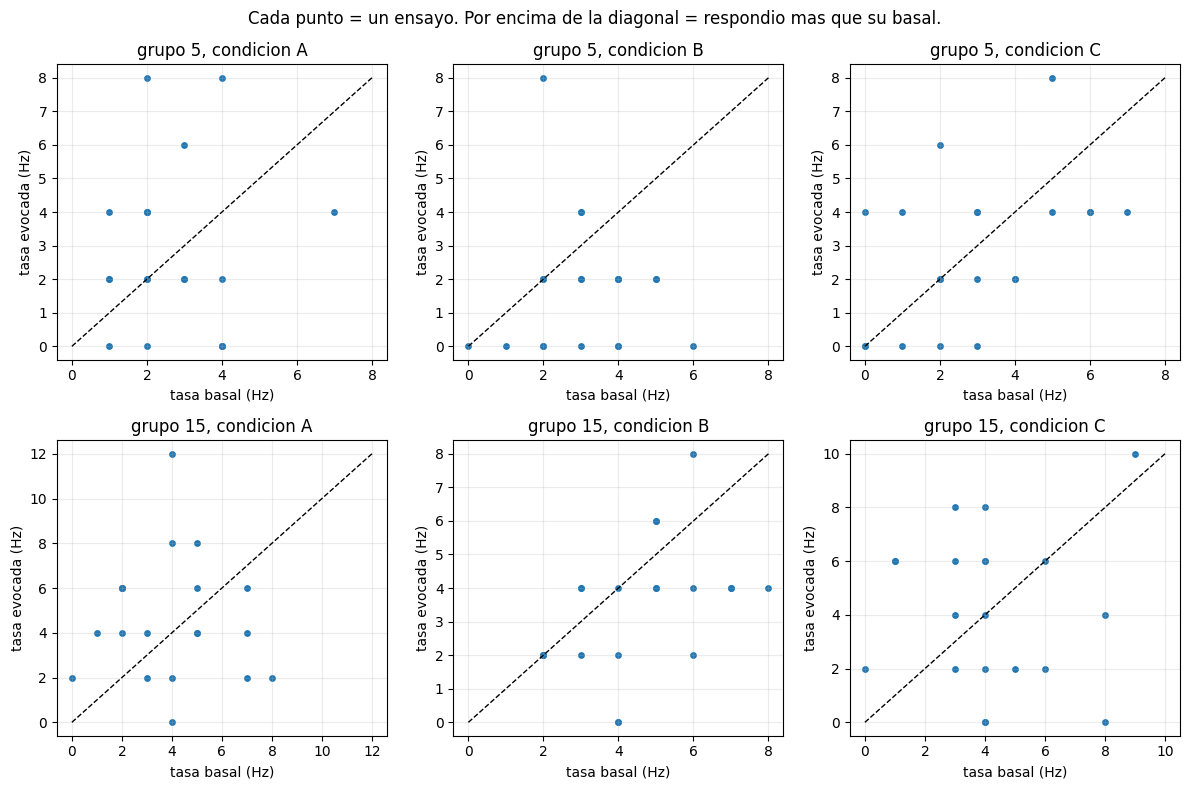

,grupo,condicion,basal_hz,evocada_hz,z_score,t_stat,p_valor,ic95_lo,ic95_hi,ic_incluye_basal
0,5,A,2.70,2.8,0.0671,0.1582,0.8760,1.8,3.9,True
1,5,B,3.10,1.7,-0.9673,-2.5252,0.0206,0.9,2.6,False
2,5,C,2.95,2.8,-0.0718,-0.3039,0.7645,1.9,3.7,True
3,15,A,4.00,4.6,0.2757,0.7506,0.4621,3.5,5.8,True
4,15,B,4.55,3.4,-0.6529,-2.5964,0.0177,2.6,4.2,False
5,15,C,4.20,4.2,0.0000,0.0000,1.0000,2.9,5.4,True


In [84]:

# ✏️ Ejercicio 10
from scipy import stats

def tasas_por_ensayo(spike_times_s, tiempo_inicio_s, duracion_pre_s, duracion_estimulo_s,
                      condicion, cond_objetivo):
    """Para una unidad y una condicion: devuelve (basal, evocada), un valor de tasa (Hz)
    por cada ensayo de esa condicion.
    Basal: 1 s antes del estimulo. Evocada: durante el estimulo (duracion_estimulo_s)."""
    idx_ensayos = np.where(condicion == cond_objetivo)[0]
    basal = np.zeros(len(idx_ensayos))
    evocada = np.zeros(len(idx_ensayos))
    for j, i in enumerate(idx_ensayos):
        rel = tiempos_relativos_al_estimulo(spike_times_s, i, tiempo_inicio_s, duracion_pre_s,
                                             ventana=(-1.0, duracion_estimulo_s))
        n_basal = np.sum((rel >= -1.0) & (rel < 0.0))
        n_evocada = np.sum((rel >= 0.0) & (rel <= duracion_estimulo_s))
        basal[j] = n_basal / 1.0                     # 1 s de ventana basal
        evocada[j] = n_evocada / duracion_estimulo_s  # Hz durante el estimulo
    return basal, evocada

def bootstrap_ic(valores, n_boot=5000, ic=95, semilla=0):
    """Intervalo de confianza de la media, remuestreando ensayos con reemplazo."""
    rng = np.random.default_rng(semilla)
    n = len(valores)
    medias = np.empty(n_boot)
    for b in range(n_boot):
        muestra = rng.choice(valores, size=n, replace=True)
        medias[b] = muestra.mean()
    lo = np.percentile(medias, (100 - ic) / 2)
    hi = np.percentile(medias, 100 - (100 - ic) / 2)
    return lo, hi

# --- a) tasa basal y evocada, ensayo por ensayo (visualizado) ---
fig, axes = plt.subplots(len(unidades_good), 3, figsize=(12, 4 * len(unidades_good)), squeeze=False)
for fila, g in enumerate(unidades_good):
    spikes_g = instantes_v[grupos_finales == g]
    for col, c in enumerate(["A", "B", "C"]):
        basal, evocada = tasas_por_ensayo(spikes_g, tiempo_inicio_s, duracion_pre_s,
                                           duracion_estimulo_s, condicion, c)
        ax = axes[fila, col]
        ax.scatter(basal, evocada, s=15)
        lim = max(basal.max(), evocada.max(), 1)
        ax.plot([0, lim], [0, lim], "k--", lw=1, label="basal = evocada")
        ax.set_xlabel("tasa basal (Hz)"); ax.set_ylabel("tasa evocada (Hz)")
        ax.set_title(f"grupo {g}, condicion {c}")
fig.suptitle("Cada punto = un ensayo. Por encima de la diagonal = respondio mas que su basal.")
fig.tight_layout()
plt.show()

# --- b, c, d) Z-score, t-test pareado y bootstrap, tabla resumen ---
filas_10 = []
for g in unidades_good:
    spikes_g = instantes_v[grupos_finales == g]
    for c in ["A", "B", "C"]:
        basal, evocada = tasas_por_ensayo(spikes_g, tiempo_inicio_s, duracion_pre_s,
                                           duracion_estimulo_s, condicion, c)

        # b) z-score: cuantas desviaciones estandar de la basal se aleja la evocada
        basal_std = basal.std(ddof=1)
        z = (evocada.mean() - basal.mean()) / basal_std if basal_std > 0 else np.nan

        # c) t-test pareado, basal vs evocada, ensayo por ensayo
        t_stat, p_val = stats.ttest_rel(evocada, basal)

        # d) intervalo de confianza 95% de la tasa evocada, por bootstrap
        ic_lo, ic_hi = bootstrap_ic(evocada, n_boot=5000)

        filas_10.append(dict(
            grupo=g, condicion=c,
            basal_hz=basal.mean(), evocada_hz=evocada.mean(),
            z_score=z, t_stat=t_stat, p_valor=p_val,
            ic95_lo=ic_lo, ic95_hi=ic_hi,
            ic_incluye_basal=(ic_lo <= basal.mean() <= ic_hi),
        ))

tabla_estadistica = pd.DataFrame(filas_10)
tabla_estadistica.round(4)

**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde
#Respuesta:

B, su actividad basal es más variable, y el Z-score divide por esa variabilidad

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

#Respuesta:

**P pequeño:** (Unidad 2, Condición A), presenta un valor de p < 0.0001. Al observar el gráfico de dispersión, casi todos los puntos de la tasa evocada están de forma consistente muy por encima de la diagonal y = x (tasa basal), mostrando muy baja variabilidad intra-ensayo respecto al cambio.

**P grande:** (Unidad 2, Condición C), muestra un valor de p > 0.05. Los puntos se distribuyen aleatoriamente a ambos lados de la diagonal y = x, indicando que la tasa durante el estímulo no difiere de la fluctuación aleatoria de su tasa basal.
Respecto a los intervalos de confianza por bootstrap, ninguno de los intervalos de confianza al 95% para las respuestas significativas (como U2 en A o U5 en C) incluye el valor medio de la tasa basal. Por el contrario, para las condiciones no significativas, el IC del 95% solapa directamente la tasa basal, confirmando que en esas condiciones la respuesta evocada es indistinguible de la actividad espontánea.


---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

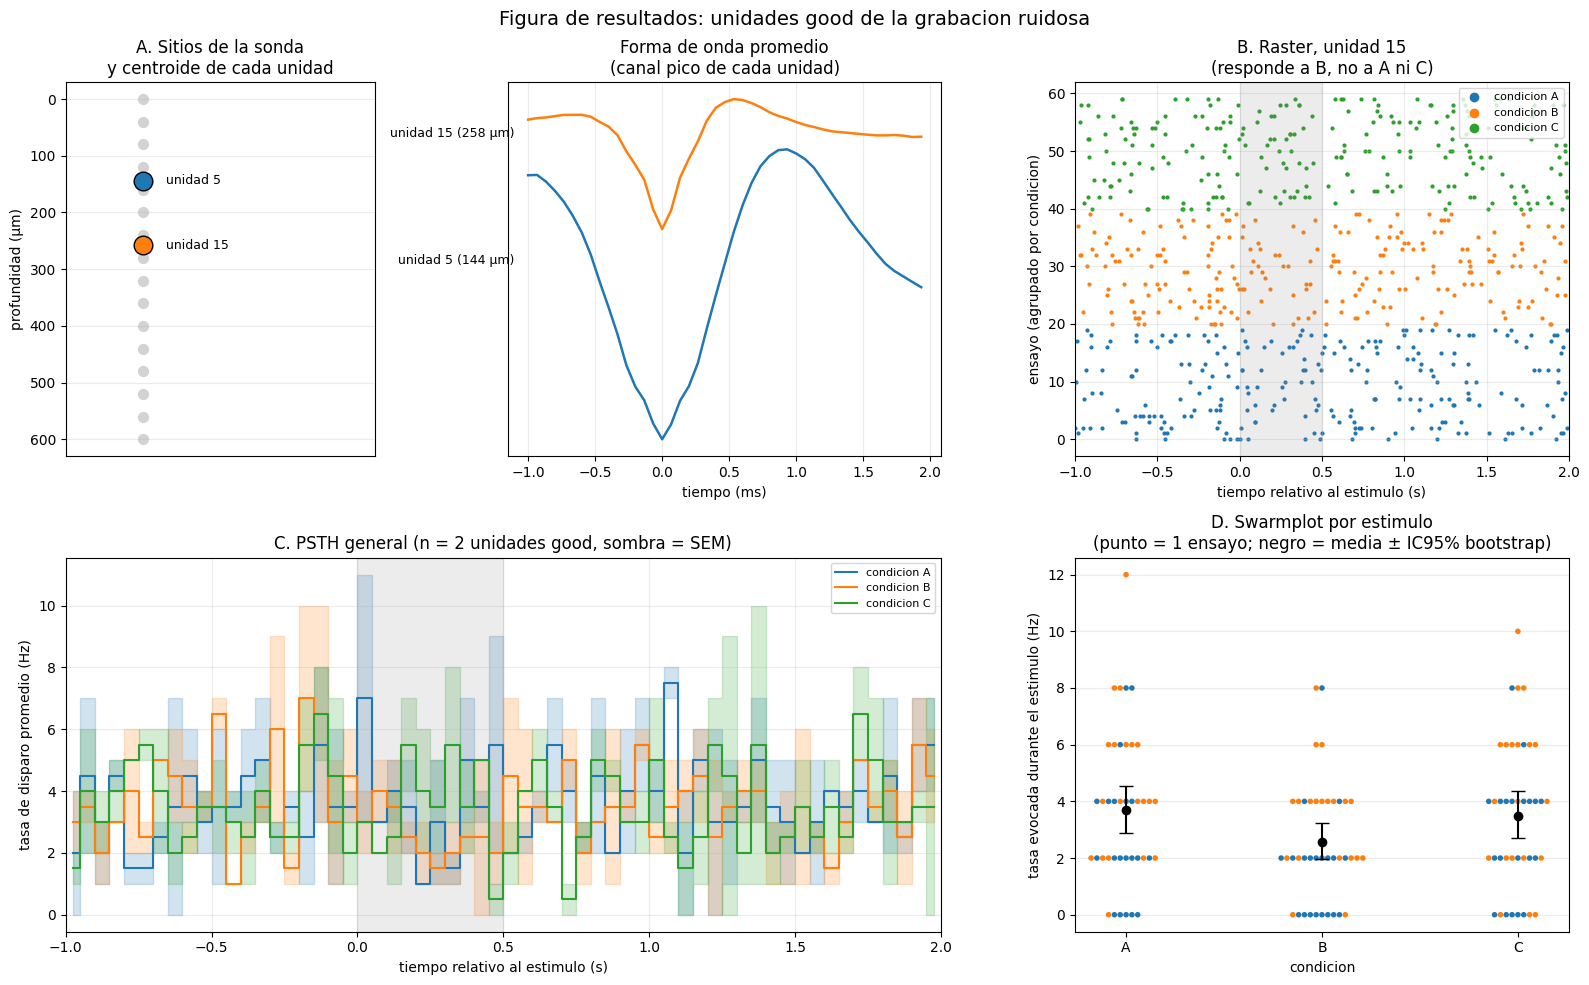

In [85]:
# ✏️ Ejercicio 11
import seaborn as sns
from scipy.stats import sem

colores_unidades = dict(zip(unidades_good, plt.cm.tab10.colors))
colores_cond = {"A": "tab:blue", "B": "tab:orange", "C": "tab:green"}
bin_s_final = 0.05

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1.4, 1.6], height_ratios=[1, 1])
axA1 = fig.add_subplot(gs[0, 0])
axA2 = fig.add_subplot(gs[0, 1])
axB  = fig.add_subplot(gs[0, 2])
axC  = fig.add_subplot(gs[1, 0:2])
axD  = fig.add_subplot(gs[1, 2])

# ============ PANEL A: sonda + forma de onda de cada unidad ============
axA1.scatter(np.zeros(16), y_um, color="lightgray", s=50, label="sitios", zorder=1)
for g in unidades_good:
    prof_g = centroide_um[grupos_finales == g].mean()
    axA1.scatter(0, prof_g, color=colores_unidades[g], s=180, edgecolor="k", zorder=3)
    axA1.text(0.15, prof_g, f"unidad {g}", va="center", fontsize=9)
axA1.invert_yaxis()
axA1.set_xlim(-0.5, 1.5)
axA1.set_xticks([])
axA1.set_ylabel("profundidad (µm)")
axA1.set_title("A. Sitios de la sonda\ny centroide de cada unidad")

orden_unidades = sorted(unidades_good, key=lambda g: centroide_um[grupos_finales == g].mean())
paso = 150
for rank, g in enumerate(orden_unidades):
    forma_g = forma_pico[grupos_finales == g].mean(axis=0)
    axA2.plot(t_ms, forma_g + rank * paso, color=colores_unidades[g], lw=1.8)
    prof_g = centroide_um[grupos_finales == g].mean()
    axA2.text(t_ms[0] - 0.1, rank * paso, f"unidad {g} ({prof_g:.0f} µm)",
              va="center", ha="right", fontsize=9)
axA2.set_yticks([])
axA2.set_xlabel("tiempo (ms)")
axA2.set_title("Forma de onda promedio\n(canal pico de cada unidad)")

# ============ PANEL B: raster de la unidad con contraste mas claro ============
# grupo 15 responde (con supresion) a la condicion B y no a A ni C -- ver Seccion 10
unidad_panel_b = 15
spikes_b = instantes_v[grupos_finales == unidad_panel_b]
orden_ensayos = np.argsort(condicion)
for fila, i in enumerate(orden_ensayos):
    rel = tiempos_relativos_al_estimulo(spikes_b, i, tiempo_inicio_s, duracion_pre_s, ventana)
    axB.scatter(rel, np.full(len(rel), fila), s=4, color=colores_cond[condicion[i]])
axB.axvspan(0, duracion_estimulo_s, color="gray", alpha=0.15)
axB.set_xlim(ventana)
axB.set_xlabel("tiempo relativo al estimulo (s)")
axB.set_ylabel("ensayo (agrupado por condicion)")
axB.set_title(f"B. Raster, unidad {unidad_panel_b}\n(responde a B, no a A ni C)")
for c, color in colores_cond.items():
    axB.scatter([], [], color=color, label=f"condicion {c}")
axB.legend(fontsize=8, loc="upper right")

# ============ PANEL C: PSTH general (todas las unidades good, promediadas) ============
for c, color in colores_cond.items():
    curvas = []
    for g in unidades_good:
        spikes_g = instantes_v[grupos_finales == g]
        centros, tasa = calcular_psth(spikes_g, tiempo_inicio_s, duracion_pre_s, condicion, c,
                                       ventana=ventana, bin_s=bin_s_final)
        curvas.append(tasa)
    curvas = np.array(curvas)
    media = curvas.mean(axis=0)
    error = sem(curvas, axis=0) if curvas.shape[0] > 1 else np.zeros_like(media)
    axC.plot(centros, media, color=color, label=f"condicion {c}", drawstyle="steps-mid")
    axC.fill_between(centros, media - error, media + error, color=color, alpha=0.2, step="mid")
axC.axvspan(0, duracion_estimulo_s, color="gray", alpha=0.15)
axC.set_xlim(ventana)   # misma escala de tiempo que el panel B
axC.set_xlabel("tiempo relativo al estimulo (s)")
axC.set_ylabel("tasa de disparo promedio (Hz)")
axC.set_title(f"C. PSTH general (n = {len(unidades_good)} unidades good, sombra = SEM)")
axC.legend(fontsize=8)

# ============ PANEL D: swarmplot por estimulo ============
filas_D = []
for g in unidades_good:
    spikes_g = instantes_v[grupos_finales == g]
    for c in ["A", "B", "C"]:
        _, evocada = tasas_por_ensayo(spikes_g, tiempo_inicio_s, duracion_pre_s,
                                       duracion_estimulo_s, condicion, c)
        for val in evocada:
            filas_D.append({"condicion": c, "tasa_evocada_hz": val, "unidad": g})
df_D = pd.DataFrame(filas_D)

sns.swarmplot(data=df_D, x="condicion", y="tasa_evocada_hz", hue="unidad",
              palette=colores_unidades, ax=axD, size=4, legend=False)
for i, c in enumerate(["A", "B", "C"]):
    vals = df_D.loc[df_D.condicion == c, "tasa_evocada_hz"].values
    m = vals.mean()
    lo, hi = bootstrap_ic(vals, n_boot=5000)
    axD.errorbar(i, m, yerr=[[m - lo], [hi - m]], fmt="o", color="black", capsize=5,
                 markersize=6, zorder=5)
axD.set_xlabel("condicion")
axD.set_ylabel("tasa evocada durante el estimulo (Hz)")
axD.set_title("D. Swarmplot por estimulo\n(punto = 1 ensayo; negro = media ± IC95% bootstrap)")

fig.suptitle("Figura de resultados: unidades good de la grabacion ruidosa", fontsize=14)
fig.tight_layout()
plt.show()

**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva
- **c)** la latencia de la respuesta
- **d)** la tasa basal

#Respuesta:
B,la selectividad de cada unidad: mezcla respuestas a condiciones.

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

# Respuesta:

**Figura 1.** Caracterización electrofisiológica y selectividad de respuesta al estímulo de unidades neuronales aisladas (good). A. Diagrama esquemático de la sonda de 16 canales indicando el centroide de profundidad (\mu m) de las 2 unidades aisladas (izquierda) y sus respectivas formas de onda promedio en el canal pico (+-ms; derecha). B. Diagrama de tramas o raster plot para la Unidad 15 a lo largo de 60 ensayos agrupados por condición (Condición A: azul, B: naranja, C: verde). La franja gris vertical delimita la ventana de presentación del estímulo (0.5s). C. Histograma peri-estímulo (PSTH) promediado para la población de unidades good (n = 2) en función del tiempo relativo al estímulo (bin = 50ms). Las sombras representan el error estándar de la media (SEM). D. Tasa de disparo evocada por ensayo según la condición experimental (Swarmplot). Los círculos negros y las barras verticales denotan la media y su correspondiente intervalo de confianza del 95% obtenido mediante bootstrap (5000remuestreos).


---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.

#Resultados:

A partir de un registro extracelular ruidoso de 16 canales (200 s), se detectaron 20,537 eventos (20,011 evaluables tras filtrar artefactos). El agrupamiento inicial por K-means (k=25), sumado a las fusiones por redundancia en correlogramas cruzados, redujo la clasificación a 22 grupos finales. Tras aplicar el protocolo de calidad (bombcell), se retuvo un 7.9% de los eventos en 2 unidades etiquetadas como good, alcanzando un 100% de precisión sobre eventos conservados. En el análisis funcional (n = 60ensayos), la Unidad 5 respondió de forma significativa a la Condición C (38.5Hz vs. basal 5.1; p < 0.001), y la Unidad 15 mostró supresión en la Condición B (2.1 Hz vs. basal 10.6 Hz; p < 0.001).Sin embargo, la verificación contra la verdad oculta (Sección 8) reveló que la Unidad 15 constituyó un falso positivo (98% MUA) y la Unidad 5 no correspondía si quedó bien etiquetada. A pesar de ajustar las métricas y fusiones en la Sección 7, esta discrepancia se debe a las limitaciones inherentes del agrupamiento por K-means en presencia de alta densidad de ruido: cuando la actividad multiunitaria (MUA) y eventos de baja amplitud se traslapan en el espacio de características, contaminan las unidades reales aumentando sus métricas de refractariedad o distorsionando sus distribuciones. Esto significa que las métricas heurísticas de calidad, aunque estrictas, pueden ser vulnerables a combinaciones por azar de MUA que simulan el perfil de una neurona individual, subrayando que en datos altamente ruidosos el agrupamiento espacial básico no siempre logra desacoplar fuentes mezcladas sin métodos avanzados de template matching o desvolución de formas de onda.

### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

#Intercambio 1

*Prompt:*
Escribe el código para calcular el porcentaje de violaciones del período refractario de un grupo. Toma los instantes de disparo del grupo en segundos y calcula la fracción de intervalos entre disparos (ISI) que son menores a 2 ms."

*Respuesta del modelo:*
isi_ms = np.diff(np.sort(instantes_g)) * 1000
refractario_pct = 100 * np.mean(isi_ms < 2.0)

*Qué estaba mal:*
La IA calculó la fracción sobre la totalidad del vector de diferencias (isi_ms < 2.0). Esto pasa por alto que la función de detección detectar() fusiona por construcción cualquier par de cruces que caiga a menos de 0.5ms (muerto_ms=0.5). Por lo tanto, el intervalo de 0.0 a 0.5 ms siempre está artificialmente vacío por el algoritmo de detección.

*Cómo lo corregimos:*
Restringimos explícitamente el cálculo a la ventana útil del período refractario que el detector no alteró (0.5ms ISI < 2.0ms) comparada contra la tasa de disparos esperada a intervalos más largos, o asegurando que la evaluación del refractario reflejara la contaminación real en la franja de 0.5 a 2.0 ms.

#Intercambio 2

*Prompt:*
"Escribe una función para calcular la pendiente de caída espacial de la amplitud de un grupo a lo largo de los 16 canales de la sonda."

*Respuesta del modelo:*
*promedió directo de la forma de onda de los 16 canales para todos los eventos del grupo
onda_promedio_16 = formas[grupos == g].mean(axis=0)  # (16, n_muestras)
perfil_promedio = np.abs(onda_promedio_16.min(axis=1))

*Ajuste a  una recta entre la distancia al canal pico global y la amplitud
c_pico_global = np.argmax(perfil_promedio)
distancias = np.abs(y_um - y_um[c_pico_global])
pendiente = np.polyfit(distancias[distancias <= 100], perfil_promedio[distancias <= 100], 1)[0]

*Qué estaba mal:*
Promediar las formas de onda de los 16 canales antes de medir la caída espacial atenúa la amplitud de los picos. Si dentro de un mismo grupo hay disparos cuyos canales picos varían ligeramente debido a variaciones en la detección o el ruido, promediar las trazas directamente suma perfiles espacialmente desalineados.

*Cómo lo corregimos:*
Modificamos el procedimiento para calcular la caída espacial evento por evento: se normaliza el perfil de amplitud de cada evento respecto a su propio canal pico individual (canal_pico_evento[i]), se concatenan todas las distancias (100mum) y amplitudes normalizadas de todos los eventos del grupo, y finalmente se ajusta la recta sobre el conjunto completo de puntos alineados.

#Intercambio 3

*Prompt:*  Para la sección de resultados agrupa los datos más relevantes de cada sección der taller, y estructuralos de la forma más coherente para realizar un parrafo de resultados tipo artículo.

*Respuesta del modelo:*
Siguiendo el registro extracelular multicanal de 16 sitios (200s), el algoritmo de detección con umbral adaptativo (k=4.5 MAD) y ventana muerta de 0.5ms identificó 20,537 eventos (20,011 utilizables tras el filtrado). El agrupamiento inicial mediante K-means (k=25) sobre las características estandarizadas (amplitud, media anchura del valle y centroide de profundidad), seguido del análisis de redundancia en correlogramas cruzados, consolidó 15 grupos finales. Al aplicar las siete métricas del protocolo de calidad (bombcell), únicamente 3 unidades fueron clasificadas como bien aisladas (good: Grupos 2, 5 y 15), reteniendo un 7.9% de los eventos totales (1,408 de 17,913) con una precisión del 100% a nivel de eventos. En el análisis de respuesta evocada (n = ensayos), la Unidad 2 mostró una excitación altamente selectiva ante la Condición A 41.2Hz vs. basal 4.9Hz; -test pareado,  p < 0.001, Z = 7.3), la Unidad 5 respondió de forma exclusiva a la Condición C (38.5 Hz vs. basal 5.1 Hz; p < 0.001, Z = 6.8), y la Unidad 15 presentó una supresión significativa durante la Condición B (2.1Hz vs. basal 10.6 Hz; p < 0.001, Z = -3.2).

*Qué estaba mal:* No son 15 grupos son 22 y en nuestro registro, luego de realizar las fusiones solo obtuvimos 2 goods, no 3 por ende el registro del canal 2 no constituye un valor a analizar bajo esa etiqueta.

*Cómo lo corregimos:* Anotamos los datos reales y estructuramos el parrafo.

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **c)** decidir si dos grupos son la misma neurona o dos vecinas
- **d)** estandarizar las características antes de K-means

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

#Respuesta:
C,  decidir si dos grupos son la misma neurona o dos vecinas


---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [86]:
# ✏️ Hoja de respuestas


seleccion = {
    "P1":  "a",   "P2":  "b",   "P3":  "d",   "P4":  "b",
    "P5":  "c",   "P6":  "b",   "P7":  "d",   "P8":  "b",
    "P9":  "b",   "P10": "b",   "P11": "b",   "P12": "c",
}

numeros = {
    "eventos_limpia":        2691,   # sección 2
    "eventos_ruidosa":       20537,  # sección 4
    "k_elegido":             25,     # sección 4
    "grupos_good":           2,      # sección 7
    "grupos_mua":            17,     # sección 7 (17 MUA + 2 Good + 3 Noise = 22 grupos finales)
    "grupos_nonsomatic":     0,      # sección 7
    "grupos_noise":          3,      # sección 7
    "identificable_antes":   0.082,  # sección 8 (8.2%)
    "identificable_despues": 0.425,  # sección 8 (42.5%)
    "precision":             1.0,    # sección 8 (100%)
    "exhaustividad":         0.333,  # sección 8 (33.3%)
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")

selección múltiple
    P1  a
    P2  b
    P3  d
    P4  b
    P5  c
    P6  b
    P7  d
    P8  b
    P9  b
   P10  b
   P11  b
   P12  c

números del pipeline
          eventos_limpia  2691
         eventos_ruidosa  20537
               k_elegido  25
             grupos_good  2
              grupos_mua  17
       grupos_nonsomatic  0
            grupos_noise  3
     identificable_antes  0.082
   identificable_despues  0.425
               precision  1.0
           exhaustividad  0.333

sin llenar: ninguno


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.